In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
import json
from scipy.stats import gmean

In [2]:
def to_tuple(data):
    if isinstance(data, list):
        return tuple(to_tuple(i) for i in data)
    elif isinstance(data, dict):
        return {k: to_tuple(v) for k, v in data.items()}
    else:
        return data


def read_csv_folder_dict(folder_path):
    """Return a dictionary with filenames as keys."""
    csv_files = list(Path(folder_path).glob("*.csv"))
    csv_files.sort()
    return {file.stem: pd.read_csv(file) for file in csv_files}


def read_json_folder(folder_path):
    """Read all JSON files from a folder into a dict of objects."""
    json_files = list(Path(folder_path).glob("*.json"))
    json_files.sort()
    json_dict = {file.stem: json.load(open(file)) for file in json_files}
    json_dict = to_tuple(json_dict)
    return json_dict


results_dfs = read_csv_folder_dict(
    "./../../data/experiment_output/fair_irl/exp_results/"
)
info_jsons = read_json_folder("./../../data/experiment_output/fair_irl/exp_info/")

organized_data = defaultdict(
    lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(pd.DataFrame)))
)
organized_info = defaultdict(
    lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
)
for filename in results_dfs:
    weight_adjusts = info_jsons[filename]["WEIGHT_ADJUSTS"]
    dataset = info_jsons[filename]["DATASET"]
    expert = info_jsons[filename]["EXPERT_ALGO"]
    bias_types = info_jsons[filename]["BIAS_TYPES"]
    organized_data[dataset][expert][bias_types][weight_adjusts] = results_dfs[filename]
    organized_info[dataset][expert][bias_types][weight_adjusts].append(
        info_jsons[filename]
    )
    pass

# Average across all trials for each dataset, expert, bias type, and weight adjustment
averaged_data = defaultdict(
    lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(pd.DataFrame)))
)
averaged_info = defaultdict(
    lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
)
for dataset in organized_info:
    for expert in organized_info[dataset]:
        for bias_types in organized_info[dataset][expert]:
            for weight_adjusts in organized_info[dataset][expert][bias_types]:
                trial_data = organized_data[dataset][expert][bias_types][weight_adjusts]
                average_series = trial_data.mean()
                averaged_data[dataset][expert][bias_types][
                    weight_adjusts
                ] = average_series
                averaged_info[dataset][expert][bias_types][weight_adjusts] = (
                    organized_info[dataset][expert][bias_types][weight_adjusts][0]
                )
del organized_info
del organized_data
del weight_adjusts
del average_series
del bias_types
del dataset
del expert
del filename
del info_jsons
del results_dfs
del trial_data

In [3]:
selected_expert = "OptAcc"

unbiased_types = [
    (),
]
biased_types = [
    # (("unbalanced_redlining", 0.2),),
    (("balanced_redlining", 0.2),),
    # (("perfectly_balanced_redlining", 0.2),),
]

unadjusted_weights = ()
# adjusted_weights = ()
# adjusted_weights = (("mul_negative_weights", 0.5),)
# adjusted_weights = ("sqrt_negative_weights",)
# adjusted_weights = ("ln_negative_weights",)
adjusted_weights = (
    (("mul_negative_weights", 0.0),),
    # (("mul_negative_weights", 0.1),),
    # (("mul_negative_weights", 0.2),),
    # (("mul_negative_weights", 0.3),),
    # (("mul_negative_weights", 0.4),),
    # (("mul_negative_weights", 0.5),),
    # (("mul_negative_weights", 0.6),),
    # (("mul_negative_weights", 0.7),),
    # (("mul_negative_weights", 0.8),),
    # (("mul_negative_weights", 0.9),),
    (("ml_debias",),),
)

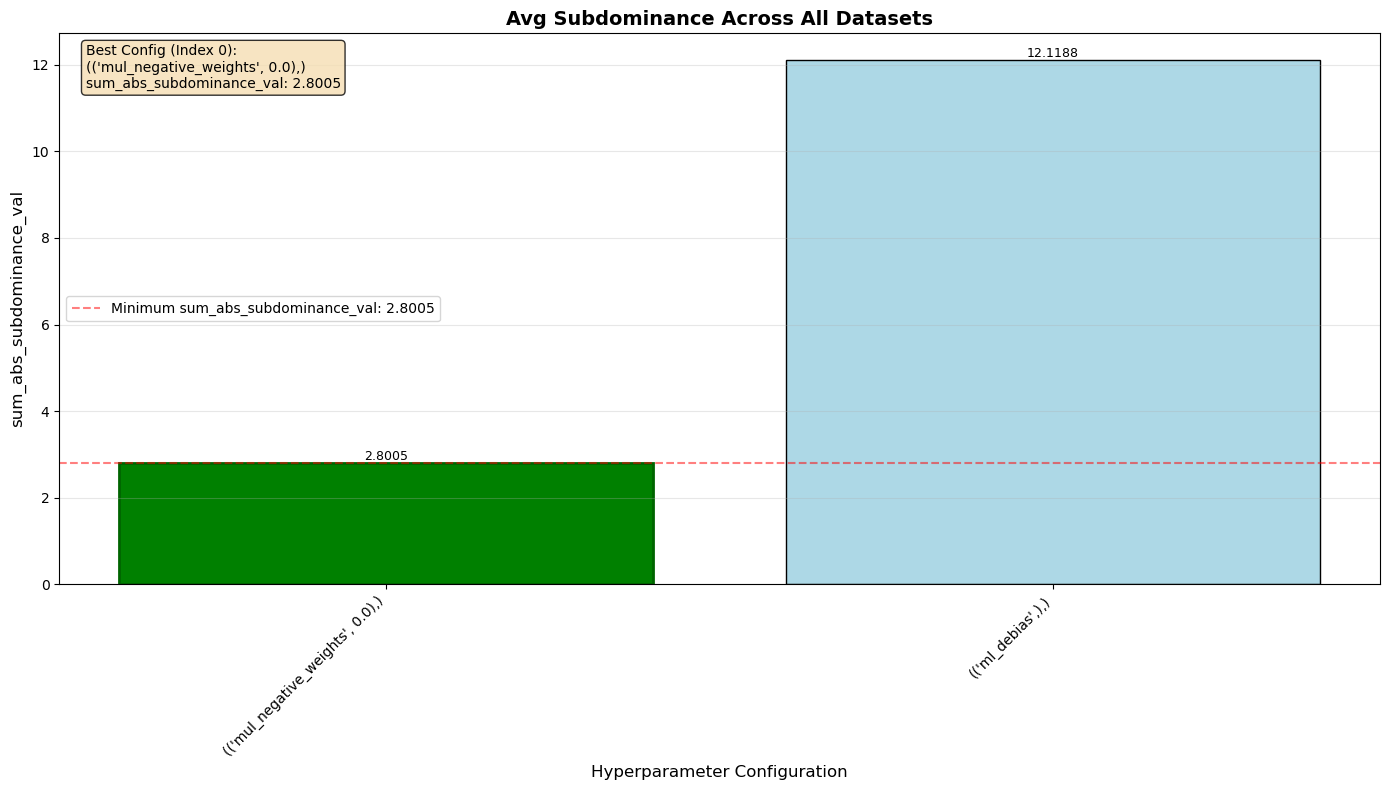

In [4]:
hyperparameter_opt_datasets = [
    "COMPAS",
    # "Boston",
    "Adult",
    "ACSIncome__MA",
    "ACSIncome__MS",
    "ACSIncome__CA",
    "ACSIncome__IL",
    "ACSIncome__AL", 
    "ACSIncome__HI",
]

# The goal is to graph the average fairness expectation error of each weight adjustment on our hyperparameter sweep
# identify what hyperparameter is best

# average across all bias types
# Average across all selected optimization datasets

# List of subdominance metrics
subdom_metric_names = ["sum_abs_subdominance_val"]

sum_abs_subdom_results_list = []

weight_adjustment_strings = []
for weight_adjustment in adjusted_weights:
    weight_adjustment_strings.append(str(weight_adjustment))
    max_abs_subdom_list = []
    sum_abs_subdom_list = []
    max_rel_subdom_list = []
    sum_rel_subdom_list = []
    for dataset in hyperparameter_opt_datasets:
        for biased_type in biased_types:
            sum_abs_subdom_list.append(
                averaged_data[dataset][selected_expert][biased_type][
                    weight_adjustment
                ]
                .loc["sum_abs_subdominance_val"]
                .item()
            )
    sum_abs_subdom_results_list.append(np.average(sum_abs_subdom_list))

subdom_metrics_list = [
    sum_abs_subdom_results_list,
]

# ======================================================================================================================================

for metric_name, metric_results in zip(subdom_metric_names, subdom_metrics_list):

    # Find the configuration with the lowest MSE
    min_metric_idx = np.argmin(metric_results)
    min_metric = metric_results[min_metric_idx]
    best_config = weight_adjustment_strings[min_metric_idx]

    # Create figure and axis
    fig, ax = plt.subplots(figsize=(14, 8))

    # Create color array - highlight the best configuration
    colors = ["lightblue"] * len(weight_adjustment_strings)
    colors[min_metric_idx] = "green"

    # Create bar plot
    x_pos = np.arange(len(weight_adjustment_strings))
    bars = ax.bar(x_pos, metric_results, color=colors, edgecolor="black")

    # Add value labels on top of bars
    for i, (bar, metric) in enumerate(zip(bars, metric_results)):
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2.0,
            height + 0.001,
            f"{metric:.4f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    # Customize the plot
    ax.set_xlabel("Hyperparameter Configuration", fontsize=12)
    ax.set_ylabel(metric_name, fontsize=12)
    ax.set_title("Avg Subdominance Across All Datasets", fontsize=14, fontweight="bold")

    # Set x-ticks to show configuration strings
    ax.set_xticks(x_pos)
    ax.set_xticklabels(weight_adjustment_strings, rotation=45, ha="right", fontsize=10)

    # Highlight the best configuration bar
    bars[min_metric_idx].set_edgecolor("darkgreen")
    bars[min_metric_idx].set_linewidth(2)

    # Add a horizontal line at the minimum MSE for reference
    ax.axhline(
        y=min_metric,
        color="red",
        linestyle="--",
        alpha=0.5,
        label=f"Minimum {metric_name}: {min_metric:.4f}",
    )

    # Add legend
    ax.legend()

    # Add text annotation for the best configuration
    ax.text(
        0.02,
        0.98,
        f"Best Config (Index {min_metric_idx}):\n{best_config}\n{metric_name}: {min_metric:.4f}",
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
    )

    # Add grid for better readability
    ax.grid(True, alpha=0.3, axis="y")

    # Adjust layout to prevent label cutoff
    plt.tight_layout()
    plt.savefig(f"./../../data/experiment_output/fair_irl/exp_plots/Avg_Sub_All.pdf", bbox_inches="tight")
    plt.show()


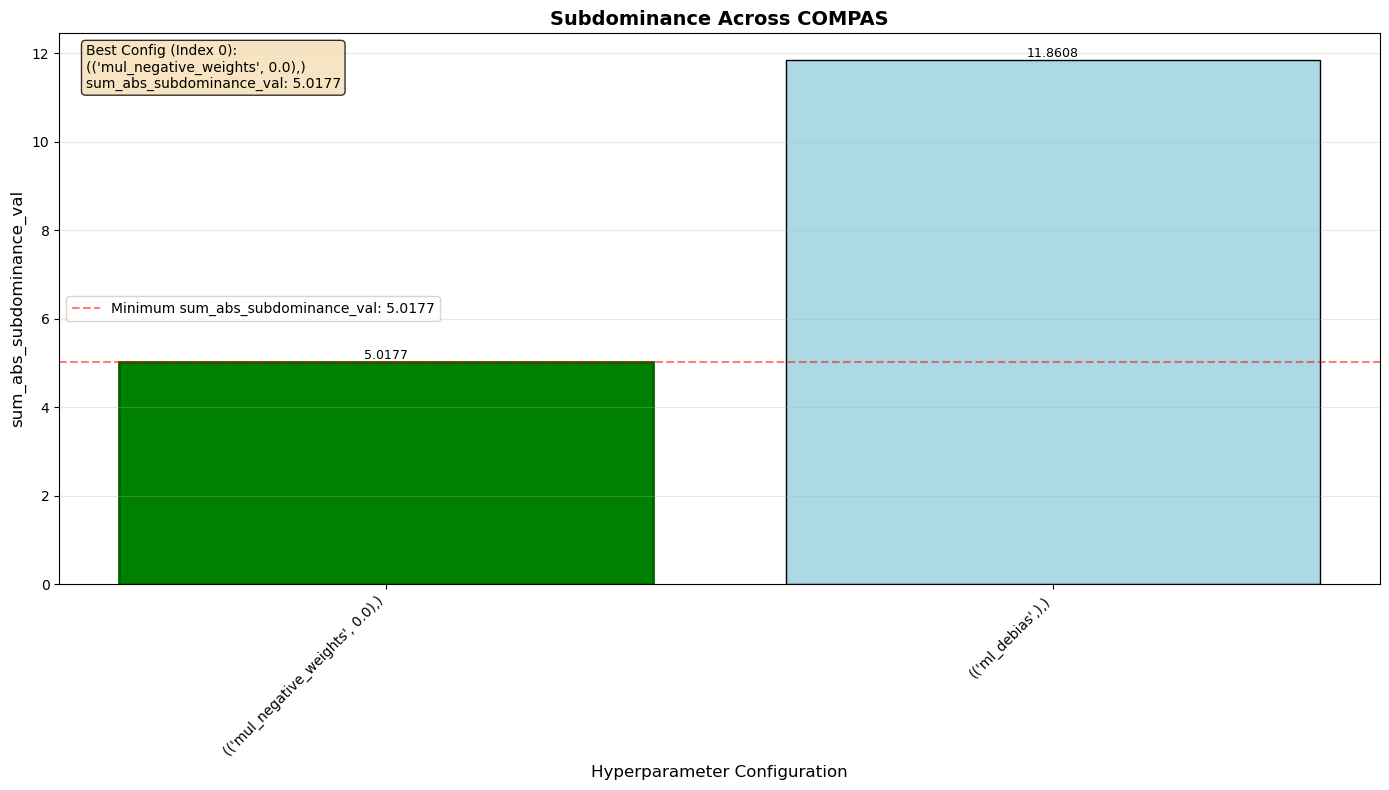

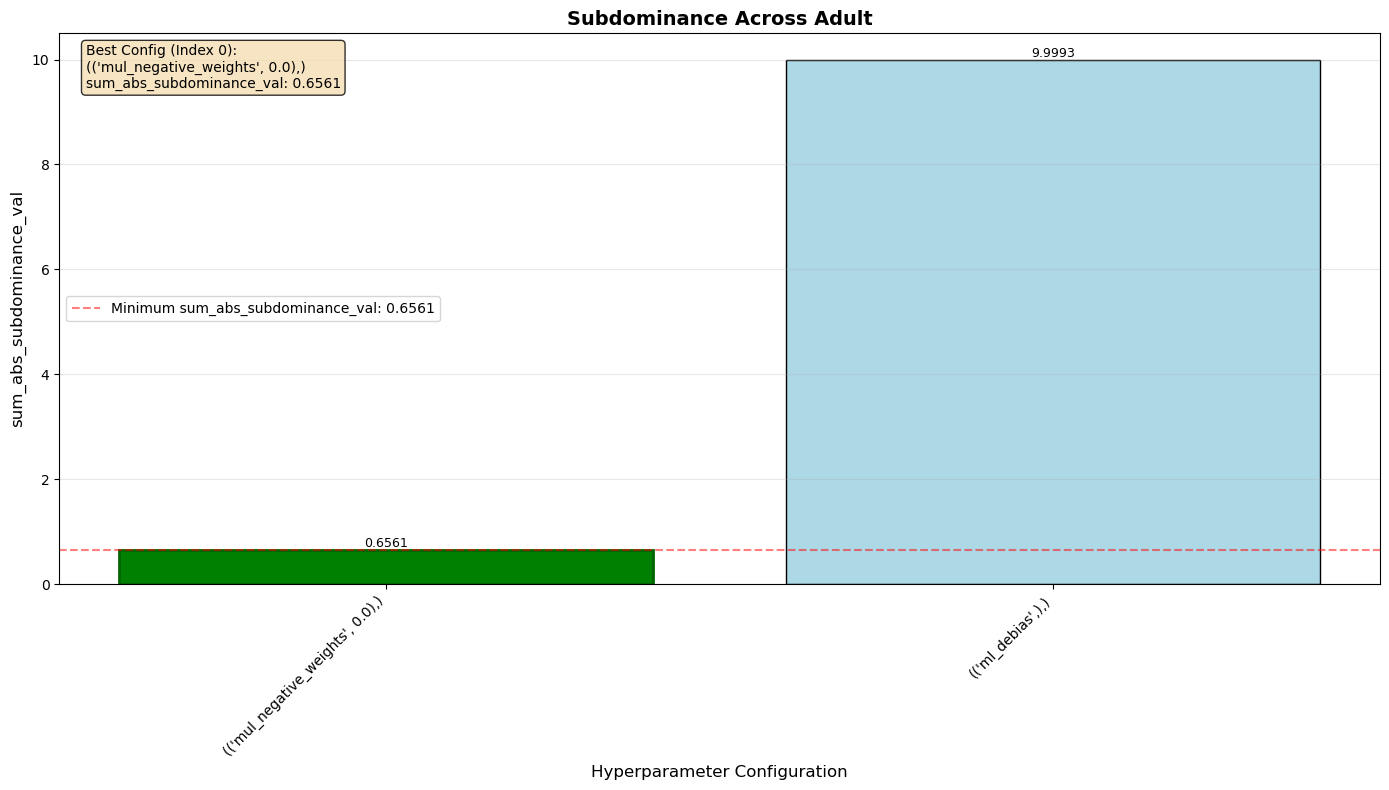

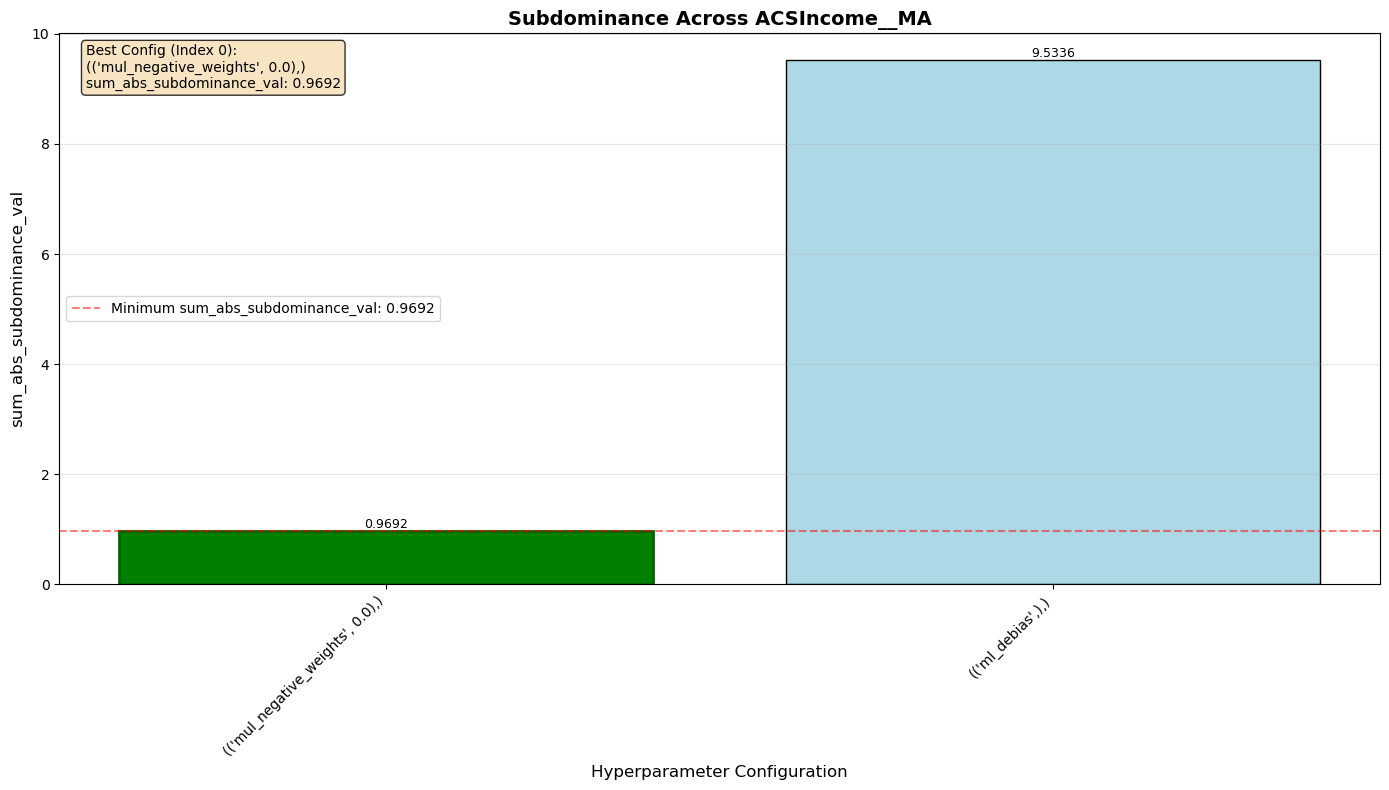

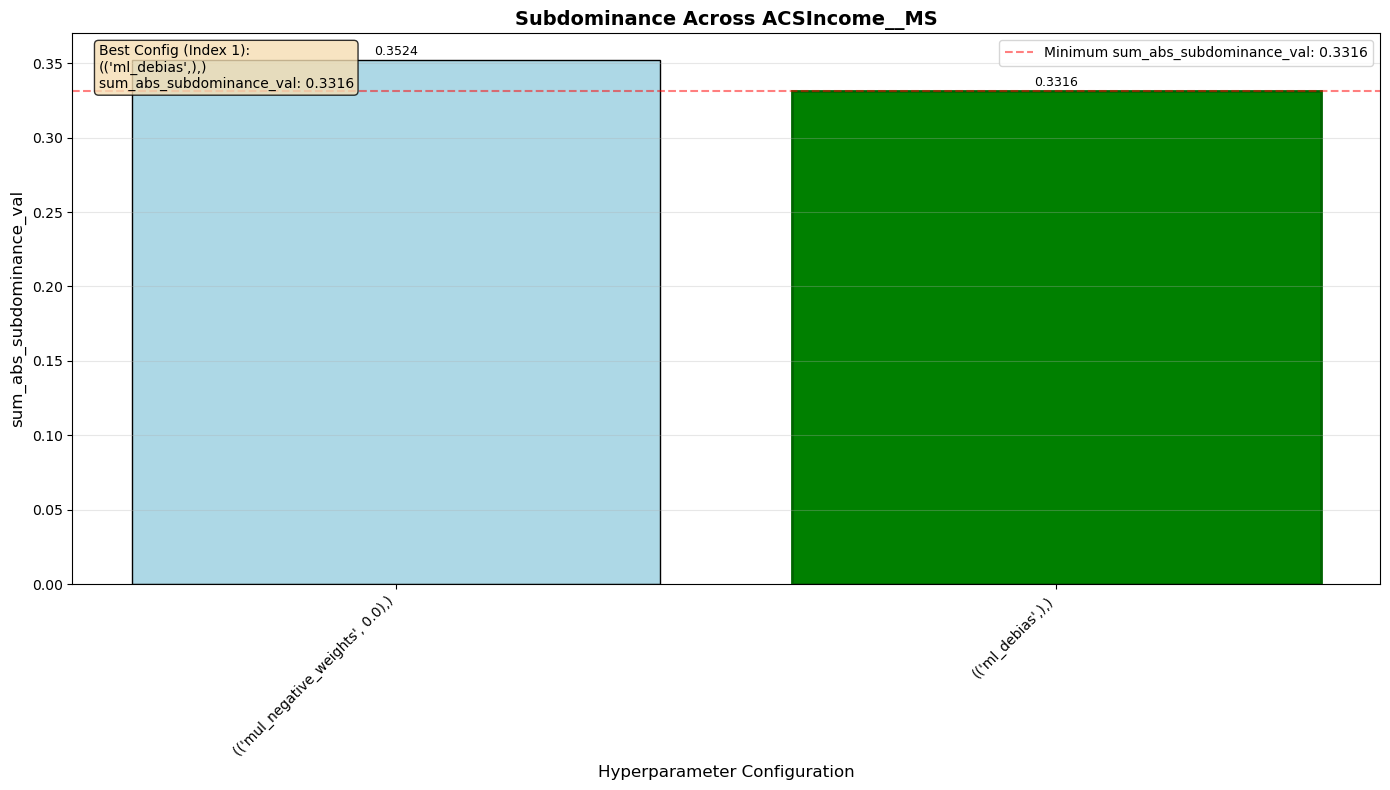

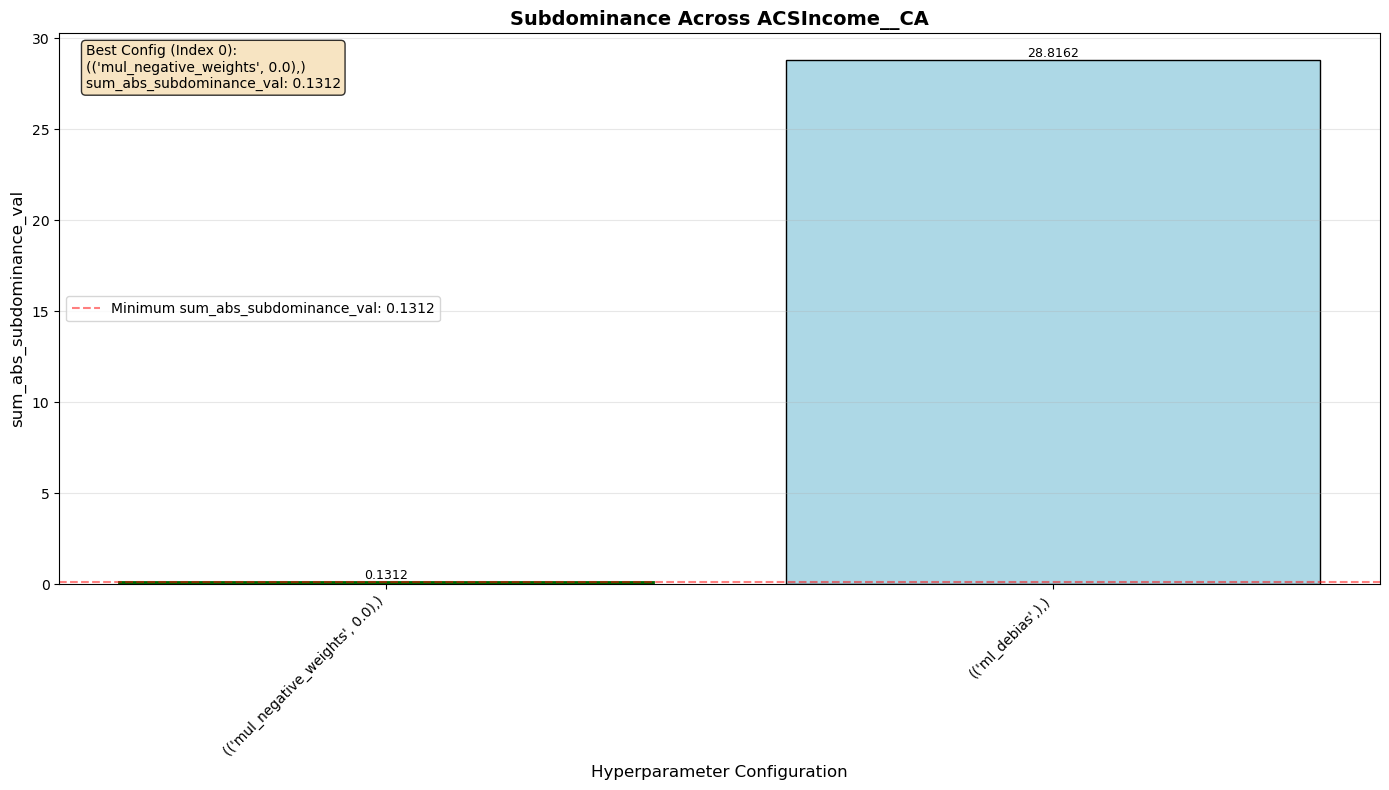

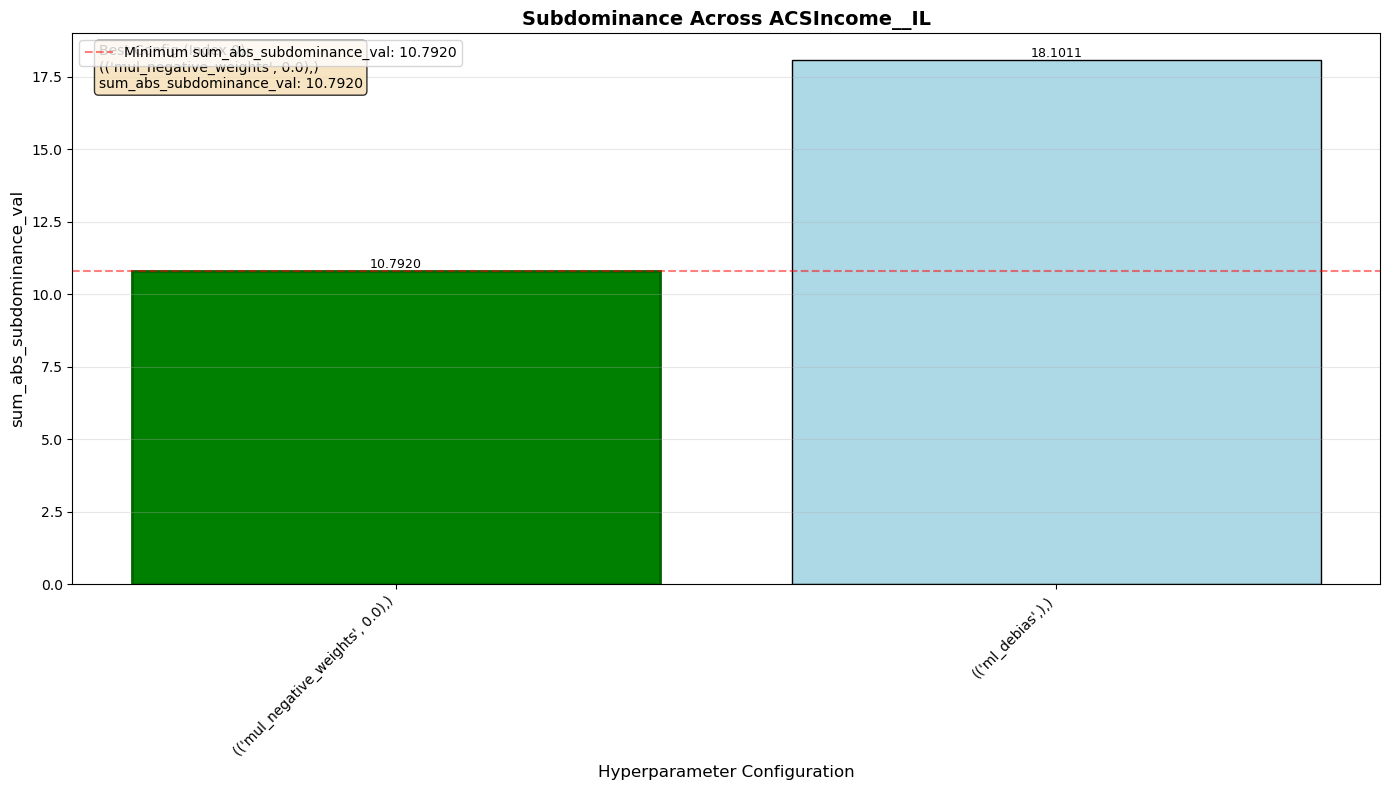

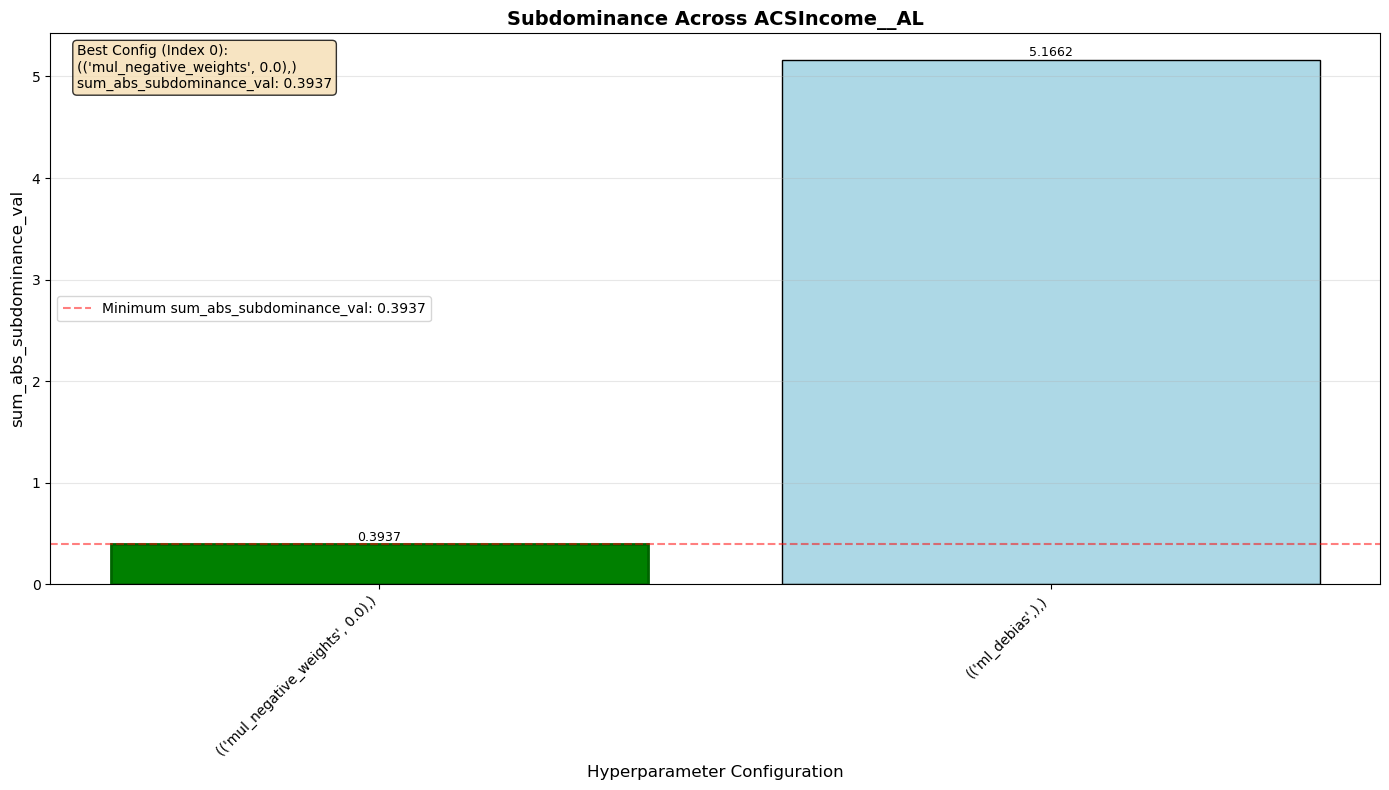

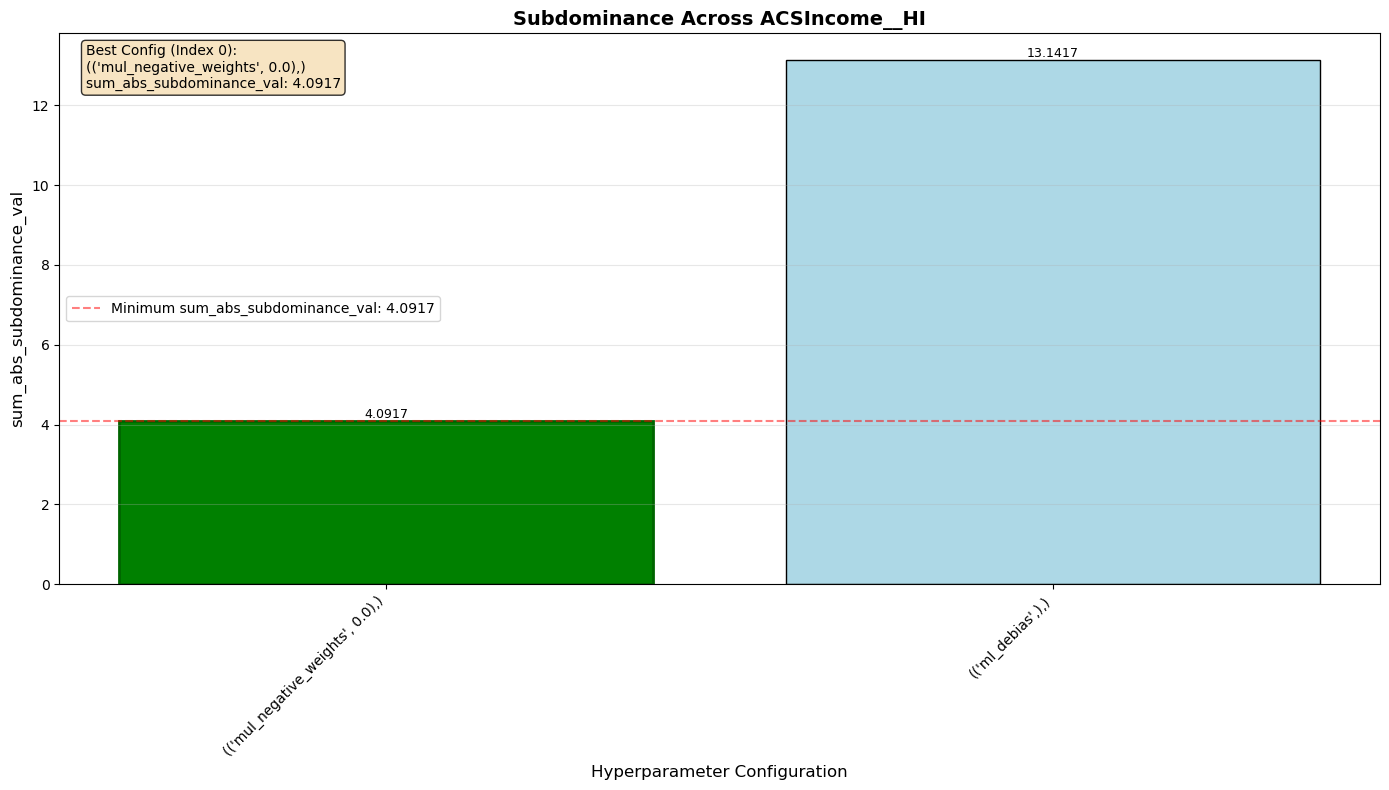

In [5]:
hyperparameter_comp_datasets = [
    "COMPAS",
    # "Boston",
    "Adult",
    "ACSIncome__MA",
    "ACSIncome__MS",
    "ACSIncome__CA",
    "ACSIncome__IL",
    "ACSIncome__AL",
    "ACSIncome__HI",
]

# Make graphs comparing the best hyperparameter configurations for the main datasets versus our "validation" datasets
# The goal is to show that our identified best hyperparameter configuration generalizes well to unseen datasets

# List of subdominance metrics
subdom_metric_names = ["sum_abs_subdominance_val"]

dataset_metrics_list = []

for dataset in hyperparameter_comp_datasets:
    all_subdom_metrics_list = []
    sum_abs_subdom_results_list = []

    weight_adjustment_strings = []
    for weight_adjustment in adjusted_weights:
        weight_adjustment_strings.append(str(weight_adjustment))
        sum_abs_subdom_list = []
        for biased_type in biased_types:
            sum_abs_subdom_list.append(
                averaged_data[dataset][selected_expert][biased_type][
                    weight_adjustment
                ]
                .loc["sum_abs_subdominance_val"]
                .item()
            )        
        sum_abs_subdom_results_list.append(np.average(sum_abs_subdom_list))
    all_subdom_metrics_list.append(sum_abs_subdom_results_list)
    dataset_metrics_list.append(all_subdom_metrics_list)

# ======================================================================================================================================

for dataset_name, dataset_metrics in zip(hyperparameter_comp_datasets, dataset_metrics_list):
    for metric_name, metric_results in zip(subdom_metric_names, dataset_metrics):

        # Find the configuration with the lowest MSE
        min_metric_idx = np.argmin(metric_results)
        min_metric = metric_results[min_metric_idx]
        best_config = weight_adjustment_strings[min_metric_idx]

        # Create figure and axis
        fig, ax = plt.subplots(figsize=(14, 8))

        # Create color array - highlight the best configuration
        colors = ["lightblue"] * len(weight_adjustment_strings)
        colors[min_metric_idx] = "green"

        # Create bar plot
        x_pos = np.arange(len(weight_adjustment_strings))
        bars = ax.bar(x_pos, metric_results, color=colors, edgecolor="black")

        # Add value labels on top of bars
        for i, (bar, metric) in enumerate(zip(bars, metric_results)):
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2.0,
                height + 0.001,
                f"{metric:.4f}",
                ha="center",
                va="bottom",
                fontsize=9,
            )

        # Customize the plot
        ax.set_xlabel("Hyperparameter Configuration", fontsize=12)
        ax.set_ylabel(metric_name, fontsize=12)
        ax.set_title(f"Subdominance Across {dataset_name}", fontsize=14, fontweight="bold")

        # Set x-ticks to show configuration strings
        ax.set_xticks(x_pos)
        ax.set_xticklabels(weight_adjustment_strings, rotation=45, ha="right", fontsize=10)

        # Highlight the best configuration bar
        bars[min_metric_idx].set_edgecolor("darkgreen")
        bars[min_metric_idx].set_linewidth(2)

        # Add a horizontal line at the minimum MSE for reference
        ax.axhline(
            y=min_metric,
            color="red",
            linestyle="--",
            alpha=0.5,
            label=f"Minimum {metric_name}: {min_metric:.4f}",
        )

        # Add legend
        ax.legend()

        # Add text annotation for the best configuration
        ax.text(
            0.02,
            0.98,
            f"Best Config (Index {min_metric_idx}):\n{best_config}\n{metric_name}: {min_metric:.4f}",
            transform=ax.transAxes,
            fontsize=10,
            verticalalignment="top",
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
        )

        # Add grid for better readability
        ax.grid(True, alpha=0.3, axis="y")

        # Adjust layout to prevent label cutoff
        plt.tight_layout()
        plt.savefig(f"./../../data/experiment_output/fair_irl/exp_plots/Sub_for_{dataset_name}.pdf", bbox_inches="tight")
        plt.show()


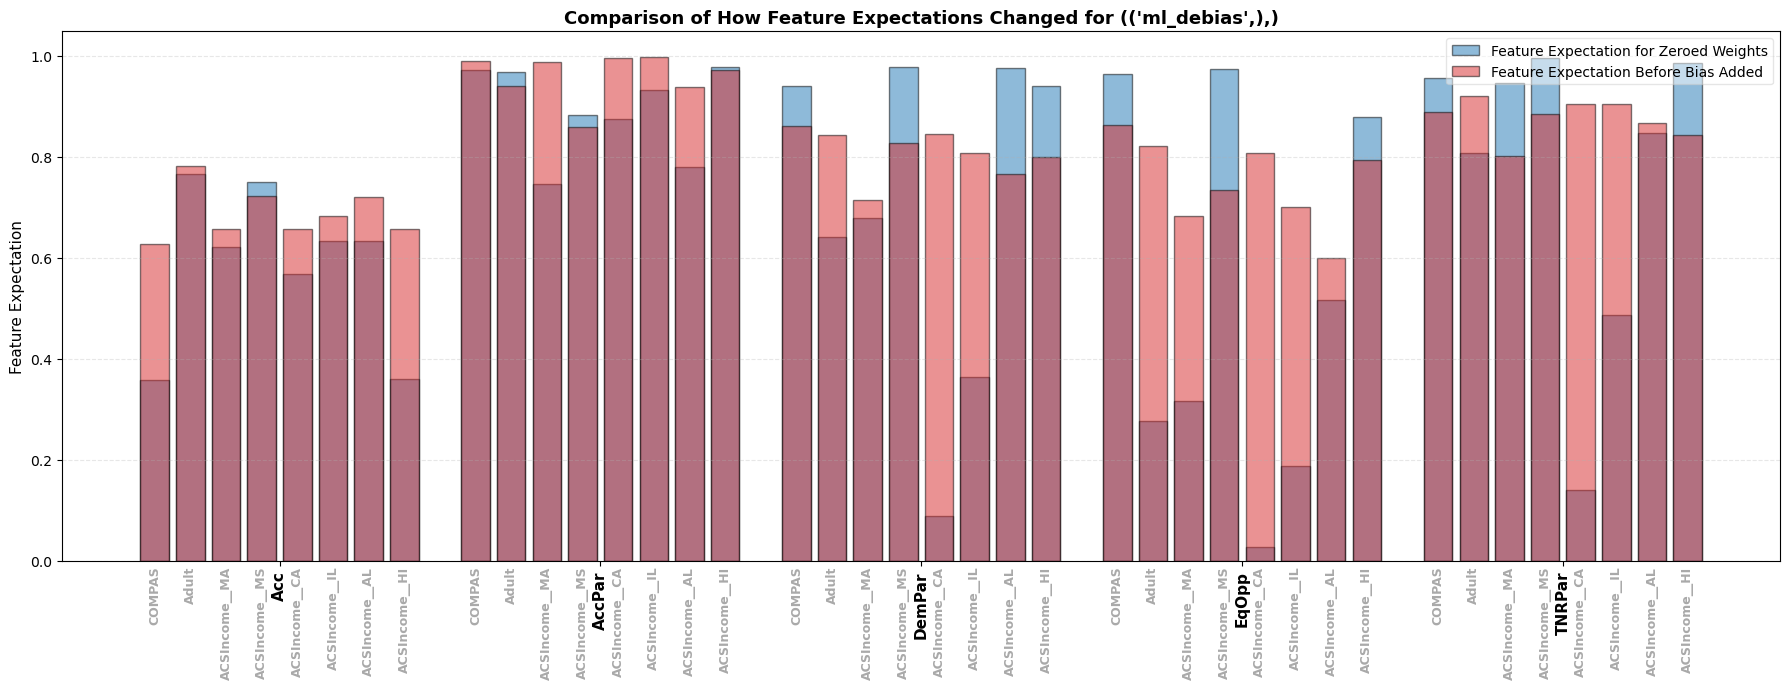

In [6]:
unbiased_types = ()
# biased_types = (("perfectly_balanced_redlining", 0.2),)
biased_types = (("balanced_redlining", 0.2),)
# biased_types = (("unbalanced_redlining", 0.2),)
# biased_types = (("threshold_swapping", 0.2),)

unadjusted_weights = ()
# adjusted_weights = (("mul_negative_weights", 0.0),)
adjusted_weights = (("ml_debias",),)
# adjusted_weights = ()


# diff_metric_df_list = []

data_config_list = []  # (Metric Prefix, Metrix Suffix, bias types, weight adjustments)
# data_config_list.append(("muL_best_", "", biased_types, unadjusted_weights))  # Original IRL FE
data_config_list.append(
    ("muL_test_", "", biased_types, adjusted_weights)
)  # Zeroed IRL FE
measurable_metrics = [
    "Acc",
    "AccPar",
    "DemPar",
    "EqOpp",
    "TNRPar",
    # "EqOdds"
]  # , "FPRPar", "FNRPar"] # removed FPRPar and FNRPar because they are effectively the same as EqOpp and TNRPar
measurable_metric_list = []
for data_config in data_config_list:
    measurable_metric_list.append(
        [data_config[0] + metric + data_config[1] for metric in measurable_metrics]
    )

selected_expert = "OptAcc"
diff_metric_list = []
dataset_list = []
for dataset in averaged_info:
    dataset_list.append(dataset)
    metric_series_list = []
    for data_config, measurable_metric in zip(data_config_list, measurable_metric_list):
        exp_results = averaged_data[dataset][selected_expert][data_config[2]][
            data_config[3]
        ]
        metric_results = exp_results.loc[measurable_metric]
        metric_results.index = measurable_metrics
        metric_series_list.append(metric_results)
    diff_sub_series = metric_series_list[0]
    diff_metric_list.append(diff_sub_series)
diff_metric_df = pd.concat(diff_metric_list, axis=1).T
diff_metric_df.index = dataset_list
# diff_metric_df_list.append(diff_metric_df)
df1 = diff_metric_df

data_config_list = []  # (Metric Prefix, Metrix Suffix, bias types, weight adjustments)
# data_config_list.append(("muE_", "_mean", biased_types, unadjusted_weights)) # Biased Demo FE
data_config_list.append(
    ("muE_test_unbiased_", "_mean", unbiased_types, unadjusted_weights)
)  # Raw Data FE
measurable_metrics = [
    "Acc",
    "AccPar",
    "DemPar",
    "EqOpp",
    "TNRPar",
    # "EqOdds"
]  # , "FPRPar", "FNRPar"] # removed FPRPar and FNRPar because they are effectively the same as EqOpp and TNRPar
measurable_metric_list = []
for data_config in data_config_list:
    measurable_metric_list.append(
        [data_config[0] + metric + data_config[1] for metric in measurable_metrics]
    )

selected_expert = "OptAcc"
diff_metric_list = []
for dataset in averaged_info:
    metric_series_list = []
    for data_config, measurable_metric in zip(data_config_list, measurable_metric_list):
        exp_results = averaged_data[dataset][selected_expert][data_config[2]][
            data_config[3]
        ]
        metric_results = exp_results.loc[measurable_metric]
        metric_results.index = measurable_metrics
        metric_series_list.append(metric_results)
    diff_sub_series = metric_series_list[0]
    diff_metric_list.append(diff_sub_series)
diff_metric_df = pd.concat(diff_metric_list, axis=1).T
diff_metric_df.index = dataset_list
# diff_metric_df_list.append(diff_metric_df)
df2 = diff_metric_df

# -------------------------------------------------------------------
# PLOT CONFIGURATION
# -------------------------------------------------------------------
n_rows = len(df1)  # number of samples per column
n_cols = len(df1.columns)  # number of metrics/columns
colors = {"df1": "tab:blue", "df2": "tab:red"}  # distinct colors
alpha = 0.5  # transparency (0 = fully transparent, 1 = opaque)
bar_width = 0.8  # width of each bar
gap_between_columns = 1.0  # horizontal gap BETWEEN metric groups
label_offset = (
    0.05  # Space between lowest bar bottom and label (as fraction of bar height)
)

fig, ax = plt.subplots(figsize=(18, 7))

# -------------------------------------------------------------------
# PLOT BARS
# -------------------------------------------------------------------
for col_idx, col_name in enumerate(df1.columns):

    # Start position for this metric group on the x‑axis
    start_x = col_idx * (n_rows + gap_between_columns)

    # Extract the values for this column from BOTH DataFrames
    vals_df1 = df1[col_name].values
    vals_df2 = df2[col_name].values

    # Plot every sample (row) in this column
    for row_idx in range(n_rows):
        x_pos = start_x + row_idx

        # Get the row label (index name)
        row_label = df1.index[row_idx]

        # Current values for both bars
        val1 = vals_df1[row_idx]
        val2 = vals_df2[row_idx]

        # -------------------------------------------------------------------
        # CALCULATE SAFE LABEL POSITION (Handles Positive & Negative Data)
        # -------------------------------------------------------------------
        # Find the absolute bottom (most negative value) between the two bars
        lowest_bottom = min(val1, val2, 0.0)

        # Determine offset distance based on bar height to keep proportional spacing
        # Use max absolute height to ensure enough space regardless of bar size
        max_height = max(abs(val1), abs(val2))
        padding_distance = max(0.01 * max_height, 0.01)

        # Calculate final y-position for label (below the lowest bar)
        label_y = lowest_bottom - padding_distance

        # Bar for DataFrame 1
        ax.bar(
            x_pos,
            val1,
            width=bar_width,
            alpha=alpha,
            color=colors["df1"],
            edgecolor="black",
        )

        # Bar for DataFrame 2 (OVERLAPS with DF1 at the SAME x_pos!)
        ax.bar(
            x_pos,
            val2,
            width=bar_width,
            alpha=alpha,
            color=colors["df2"],
            edgecolor="black",
        )

        # Add Row Index Label Below the Bars (Safe for Negative Data)
        ax.text(
            x_pos,
            label_y,
            row_label,
            ha="center",
            va="top",
            fontsize=9,
            fontweight="bold",
            rotation=90,
            color="darkgray",
            bbox=dict(facecolor="white", edgecolor="none", boxstyle="round,pad=0.2"),
        )

# -------------------------------------------------------------------
# X‑AXIS LABELS (one tick per metric group)
# -------------------------------------------------------------------
# Place a tick at the *center* of each metric group
tick_positions = [
    col_idx * (n_rows + gap_between_columns) + (n_rows - 1) / 2
    for col_idx in range(n_cols)
]
ax.set_xticks(tick_positions)
ax.set_xticklabels(df1.columns, fontsize=11, fontweight="bold", rotation=90)

# -------------------------------------------------------------------
# FINAL TOUCHES
# -------------------------------------------------------------------
ax.set_ylabel("Feature Expectation", fontsize=11)
ax.set_title(
    f"Comparison of How Feature Expectations Changed for {adjusted_weights}",
    fontsize=13,
    fontweight="bold",
)
ax.legend(
    ["Feature Expectation for Zeroed Weights", "Feature Expectation Before Bias Added"],
    loc="upper right",
    framealpha=0.5,
    fancybox=True,
)
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig(f"./../../data/experiment_output/fair_irl/exp_plots/Feat_Exp_Before_After.pdf", bbox_inches="tight")
plt.show()

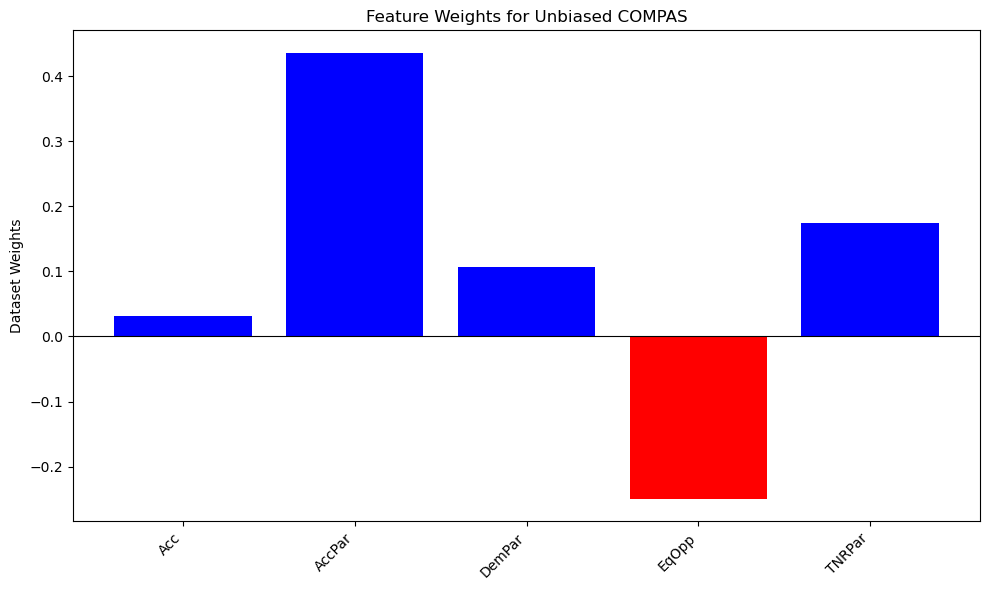

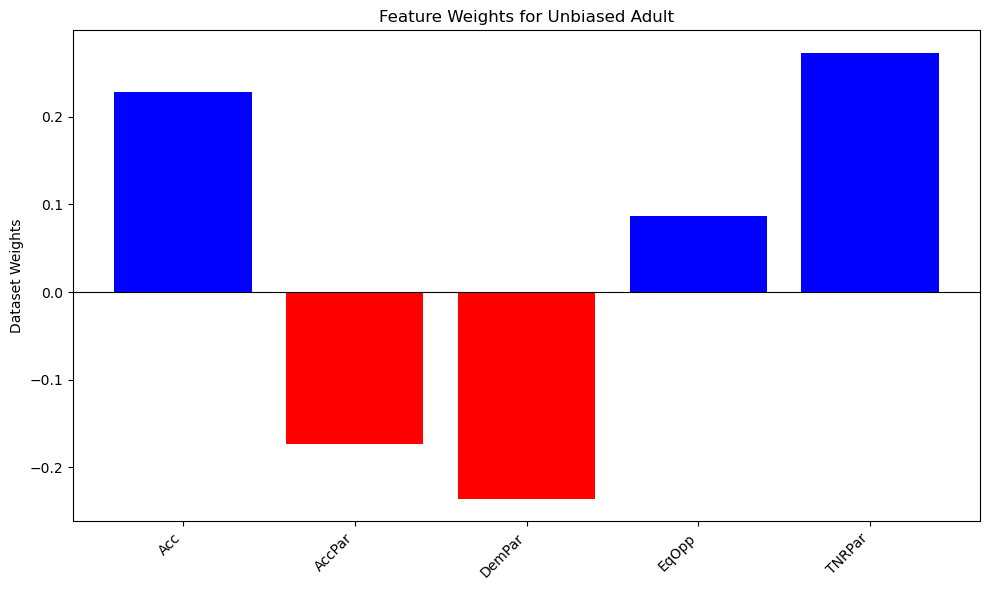

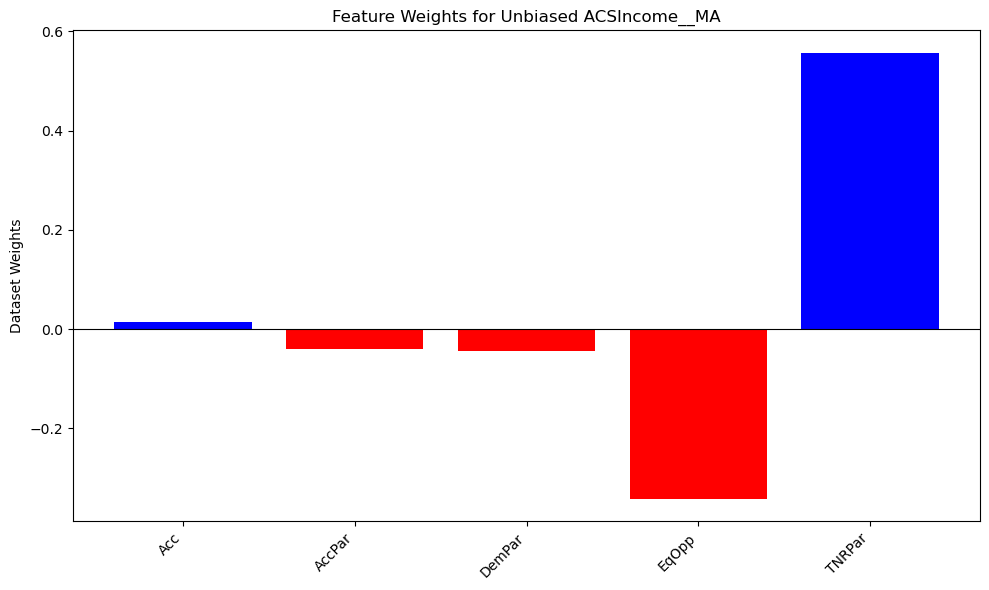

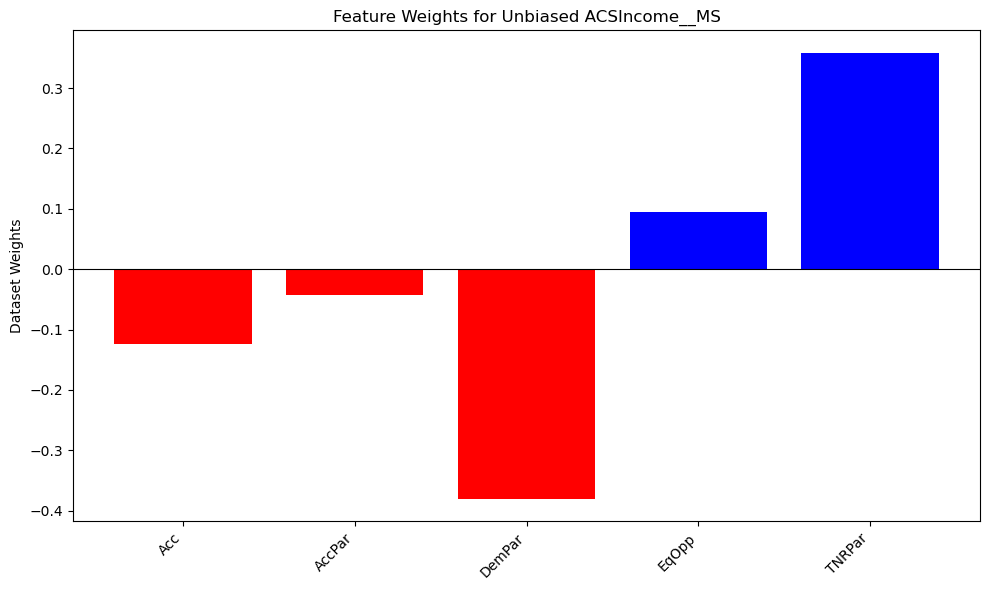

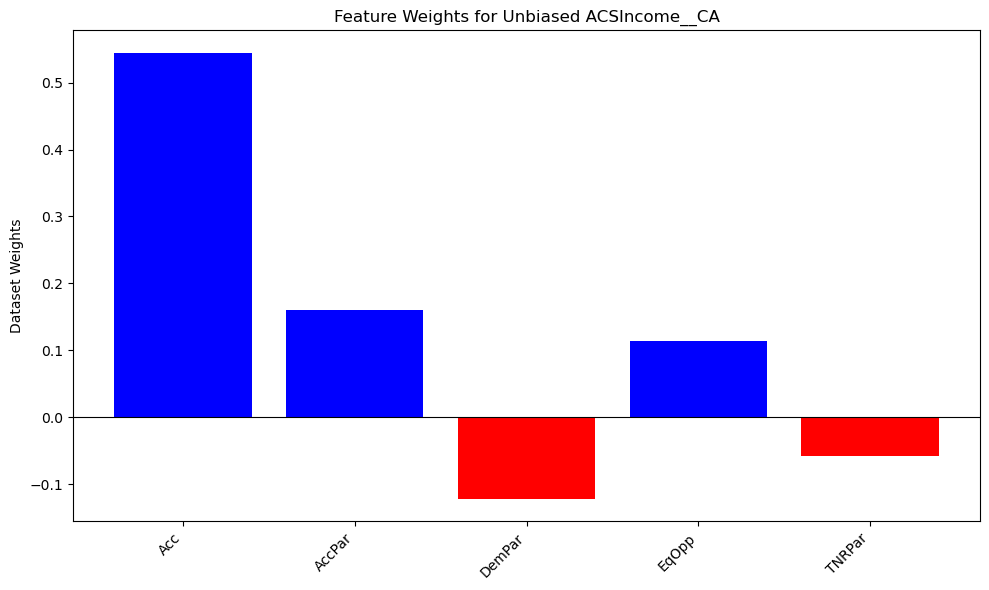

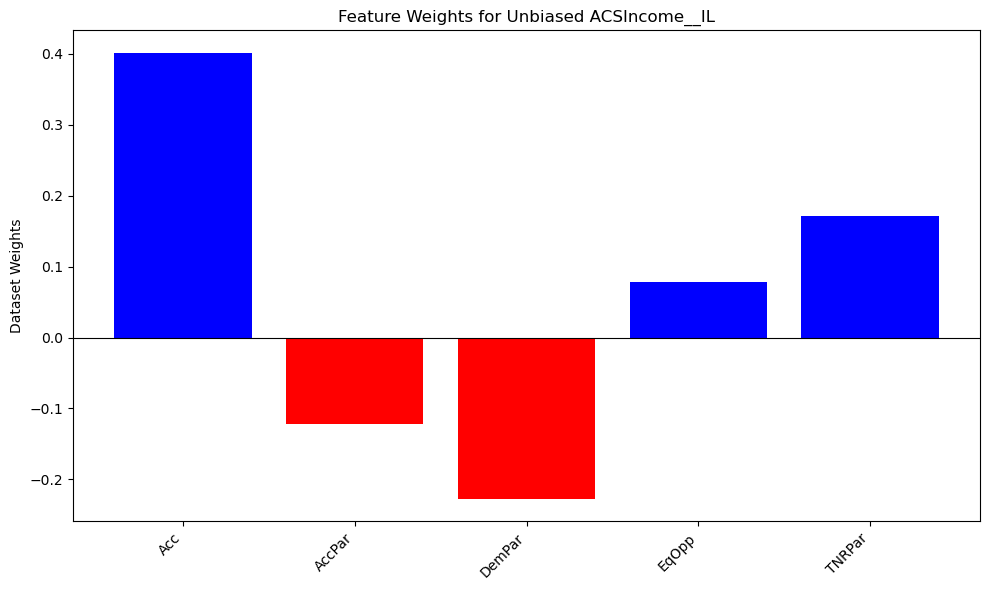

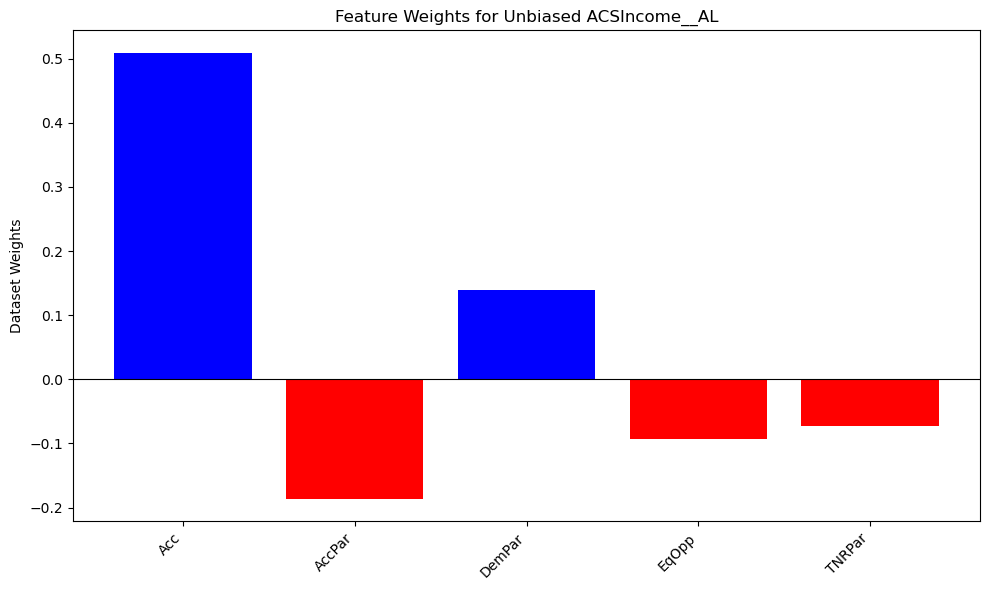

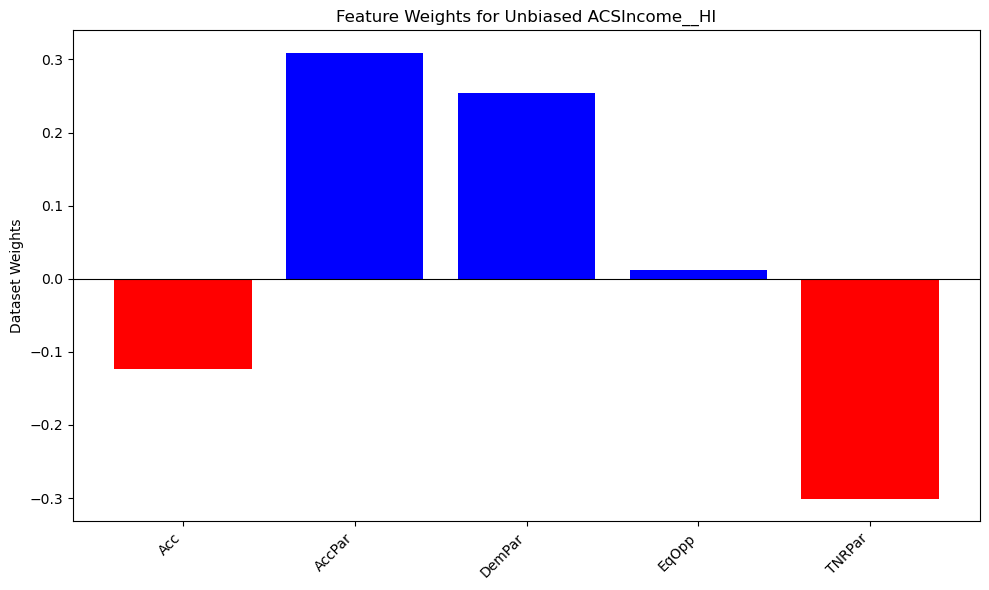

In [7]:
# The following code generates bar charts for the calculated feature weights for each dataset without any bias or weight adjustments.

selected_expert = "OptAcc"

unbiased_type = ()

unadjusted_weights = ()

all_datasets = list(averaged_data.keys())

weight_names = [] 
measurable_metrics = [
    "Acc",
    "AccPar",
    "DemPar",
    "EqOpp",
    "TNRPar",
    # "EqOdds"
]  # , "FPRPar", "FNRPar"] # removed FPRPar and FNRPar because they are effectively the same as EqOpp and TNRPar

for metric in measurable_metrics:
    weight_names.append("wL_" + metric)

raw_dataset_weights_list = []
for dataset in all_datasets:
    raw_dataset_weights = averaged_data[dataset][selected_expert][unbiased_type][unadjusted_weights][weight_names].values.tolist()
    raw_dataset_weights_list.append(raw_dataset_weights)
    
for dataset, raw_dataset_weights in zip(all_datasets, raw_dataset_weights_list):
    colors = ['blue' if weight >= 0 else 'red' for weight in raw_dataset_weights]
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(measurable_metrics, raw_dataset_weights, color=colors)
    ax.set_ylabel('Dataset Weights')
    ax.set_title(f"Feature Weights for Unbiased {dataset}")
    ax.axhline(0, color='black', linewidth=0.8)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(f"./../../data/experiment_output/fair_irl/exp_plots/Raw_Feature_Weights_{dataset}.pdf", bbox_inches="tight")
    plt.show()

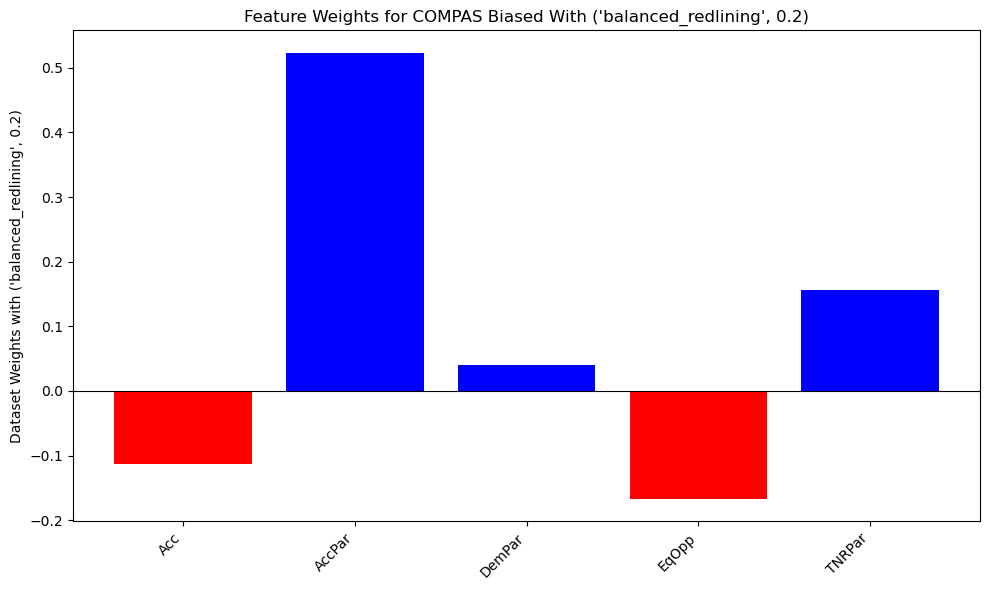

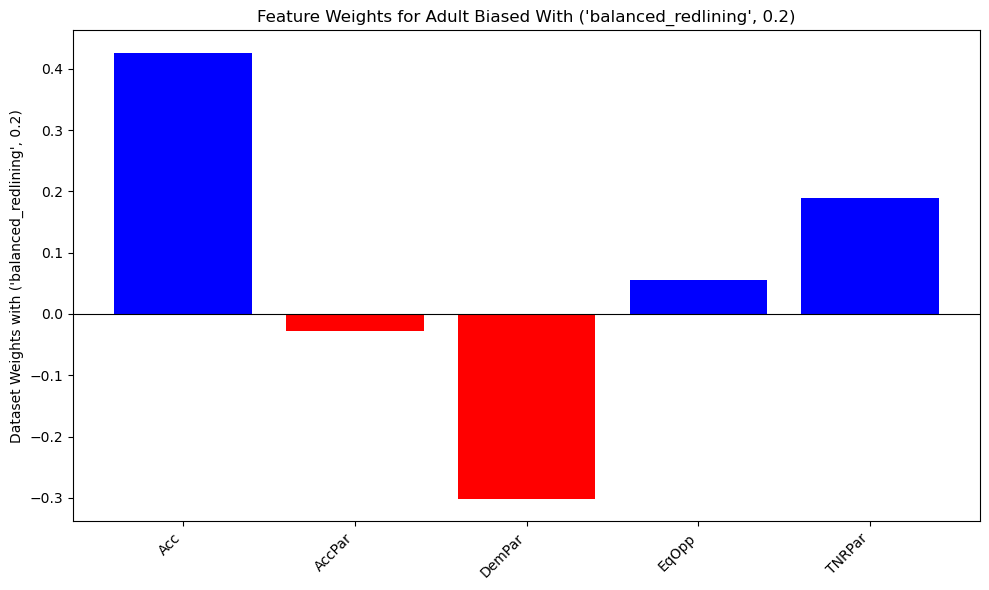

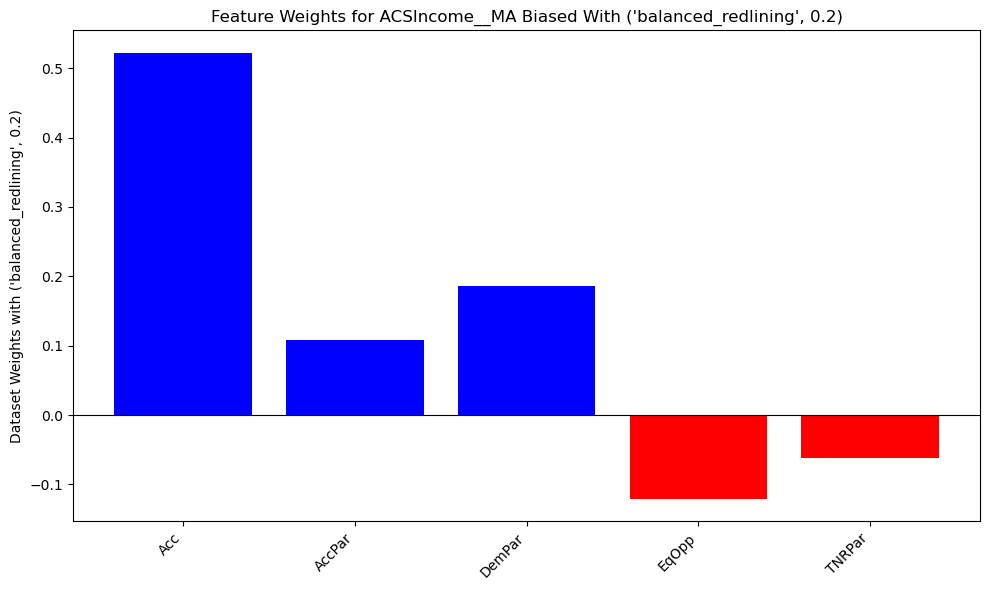

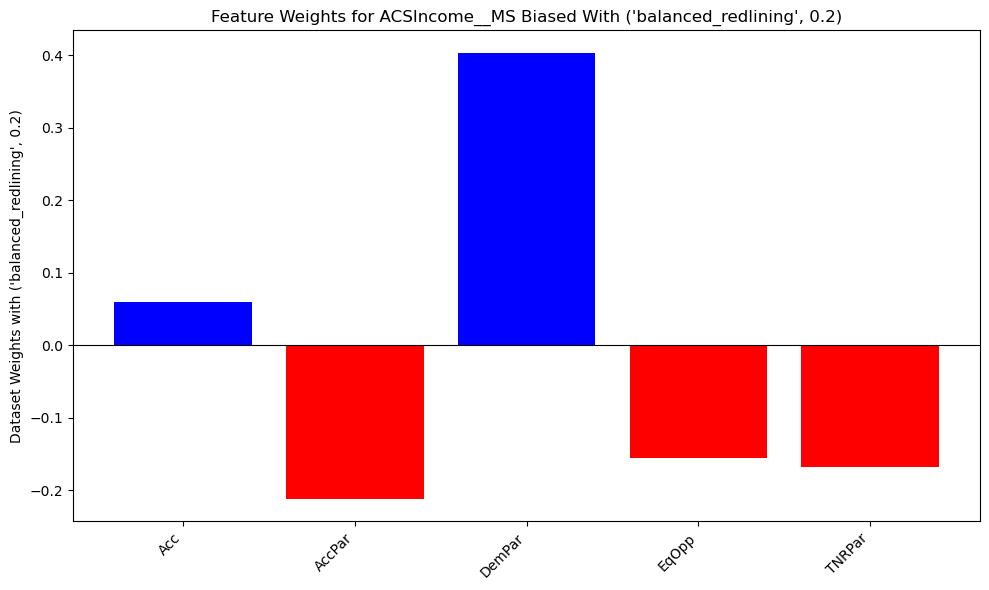

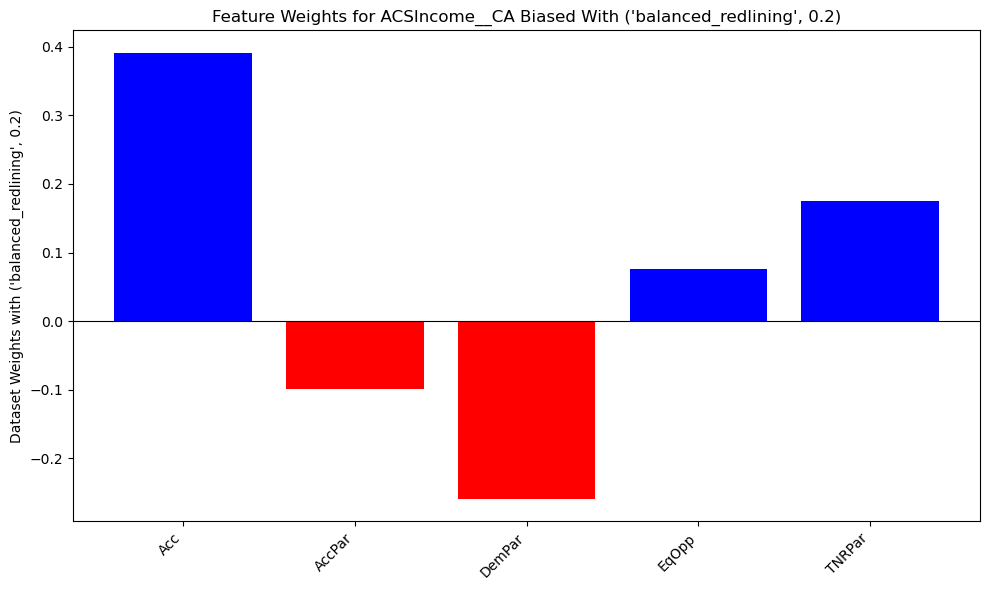

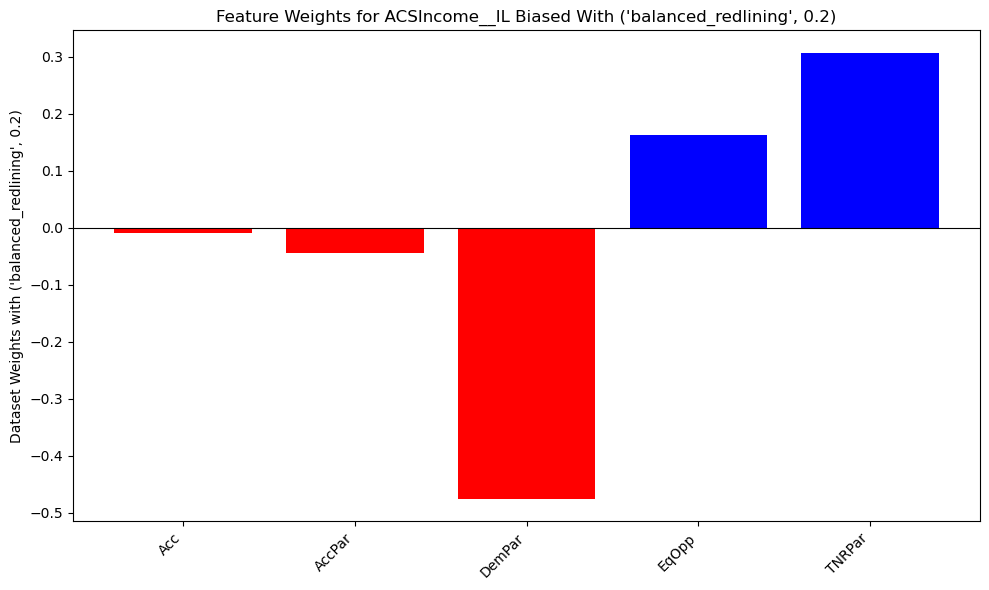

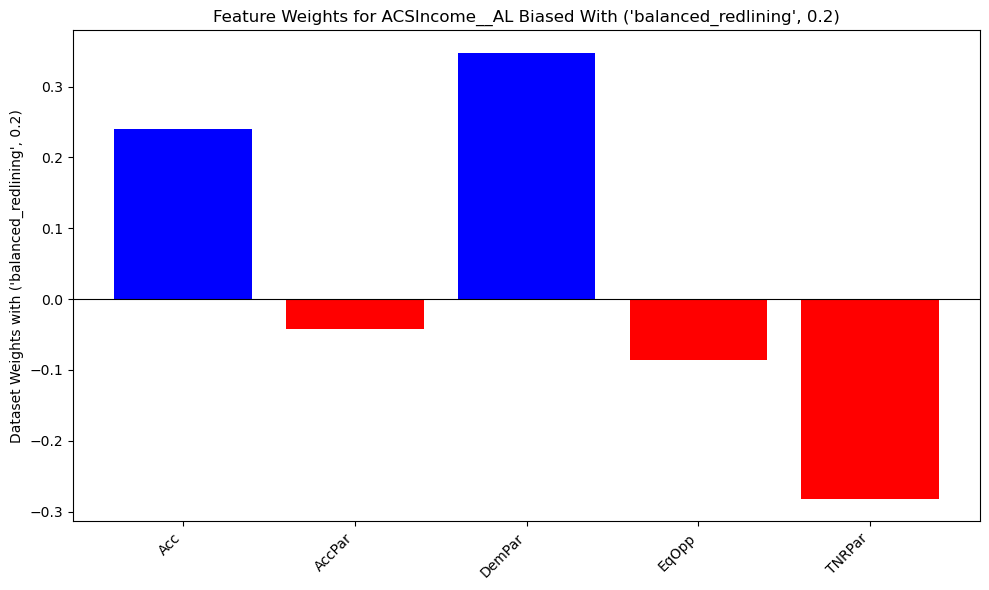

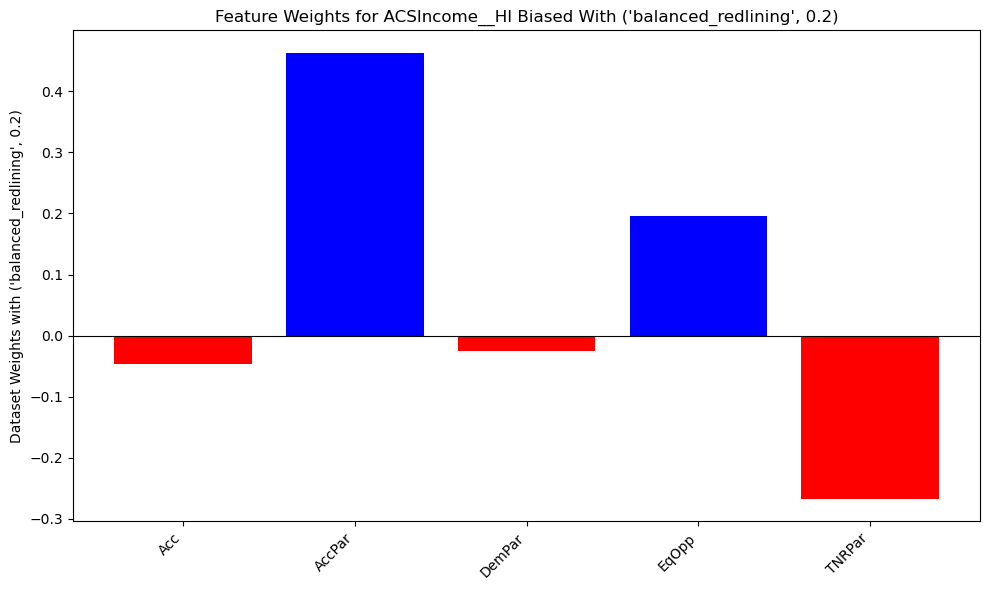

In [8]:
# The following code generates bar charts for the calculated feature weights for each dataset without weight adjustments but with bias (perfectly balanced redlining)

selected_expert = "OptAcc"

# biased_type = (("unbalanced_redlining", 0.2),)
biased_type = (("balanced_redlining", 0.2),)
# biased_type = (("perfectly_balanced_redlining", 0.2),)

unadjusted_weights = ()

all_datasets = list(averaged_data.keys())

weight_names = [] 
measurable_metrics = [
    "Acc",
    "AccPar",
    "DemPar",
    "EqOpp",
    "TNRPar",
    # "EqOdds"
]  # , "FPRPar", "FNRPar"] # removed FPRPar and FNRPar because they are effectively the same as EqOpp and TNRPar

for metric in measurable_metrics:
    weight_names.append("wL_" + metric)

raw_dataset_weights_list = []
for dataset in all_datasets:
    raw_dataset_weights = averaged_data[dataset][selected_expert][biased_type][unadjusted_weights][weight_names].values.tolist()
    raw_dataset_weights_list.append(raw_dataset_weights)
    
for dataset, raw_dataset_weights in zip(all_datasets, raw_dataset_weights_list):
    colors = ['blue' if weight >= 0 else 'red' for weight in raw_dataset_weights]
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(measurable_metrics, raw_dataset_weights, color=colors)
    ax.set_ylabel(f'Dataset Weights with {biased_type[0]}')
    ax.set_title(f"Feature Weights for {dataset} Biased With {biased_type[0]}")
    ax.axhline(0, color='black', linewidth=0.8)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(f"./../../data/experiment_output/fair_irl/exp_plots/Biased_Feature_Weights_{dataset}.pdf", bbox_inches="tight")
    plt.show()

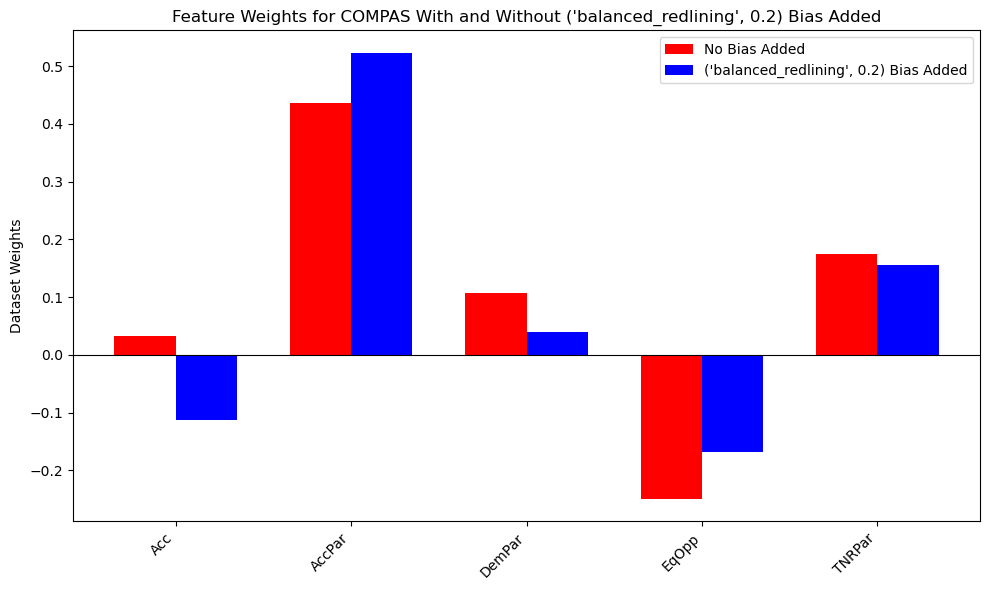

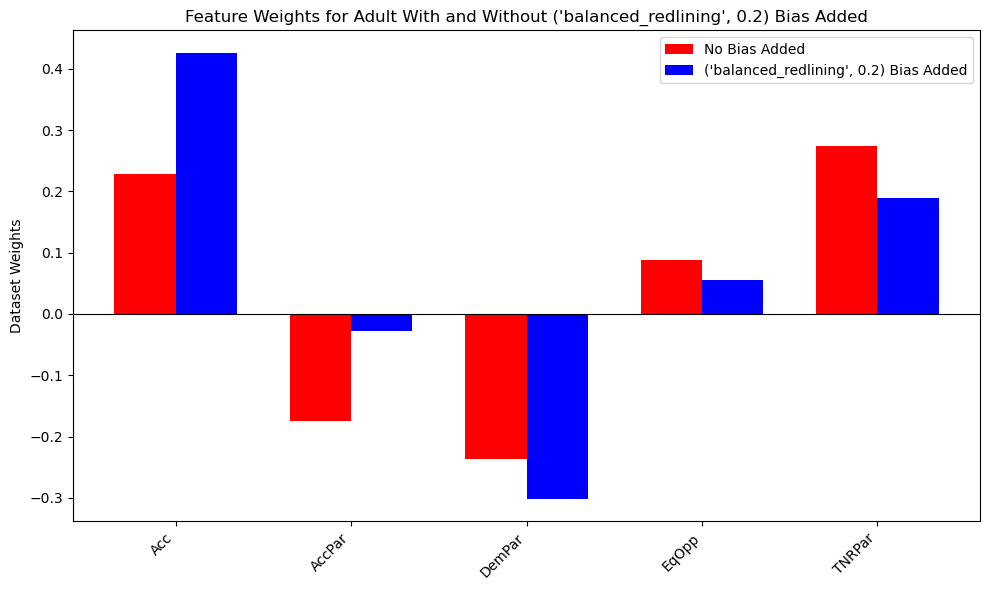

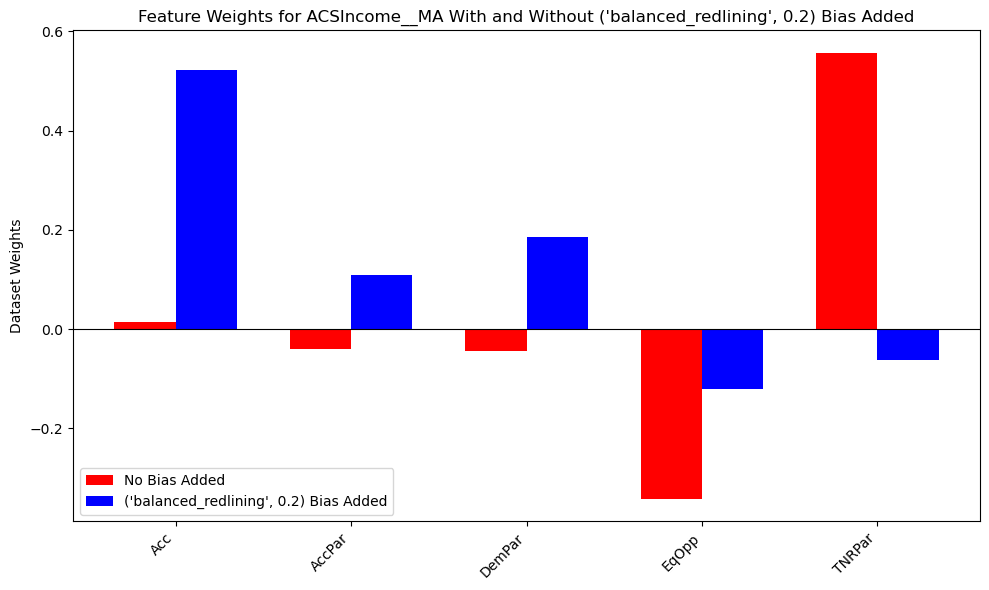

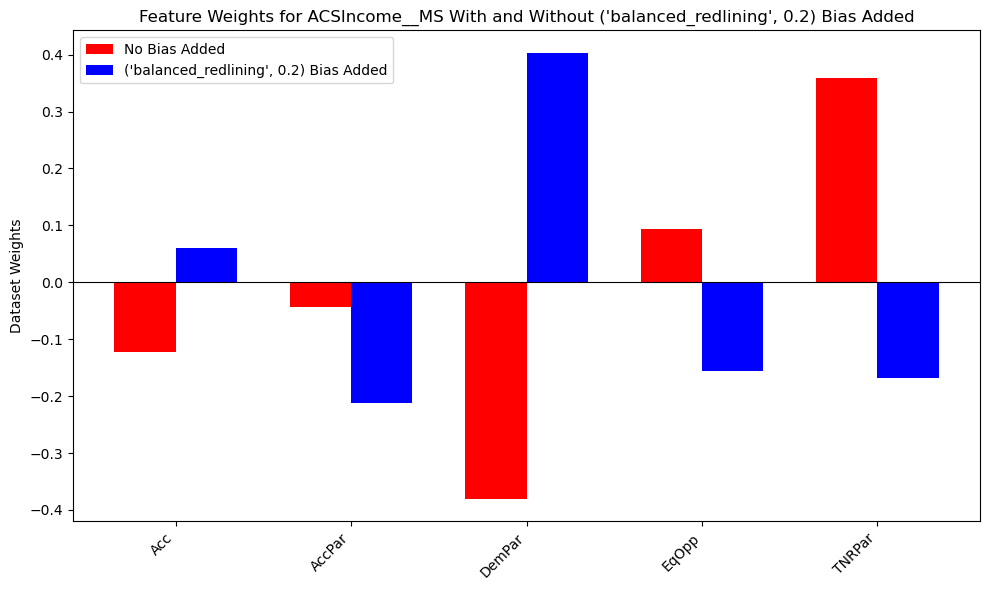

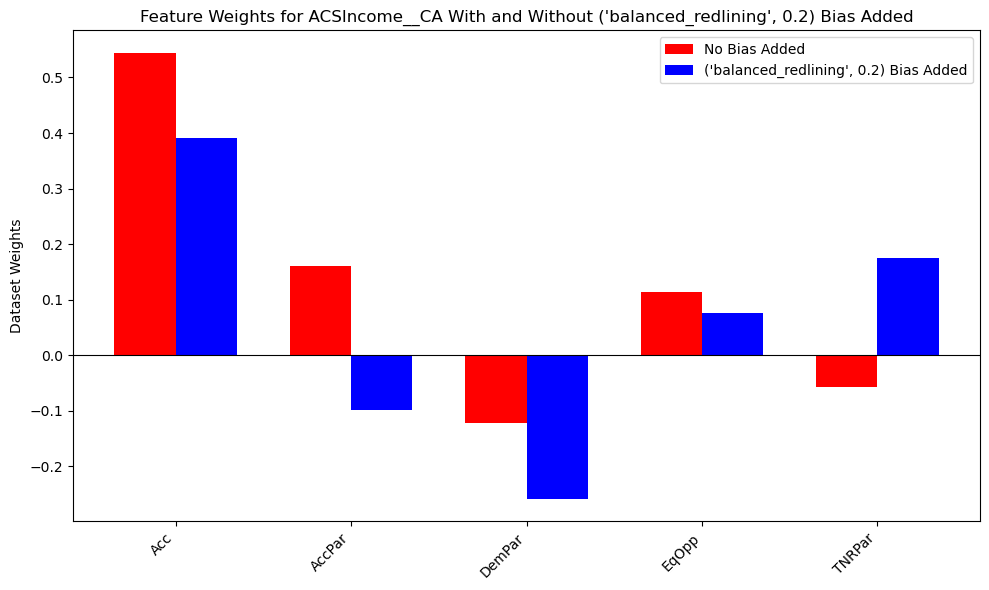

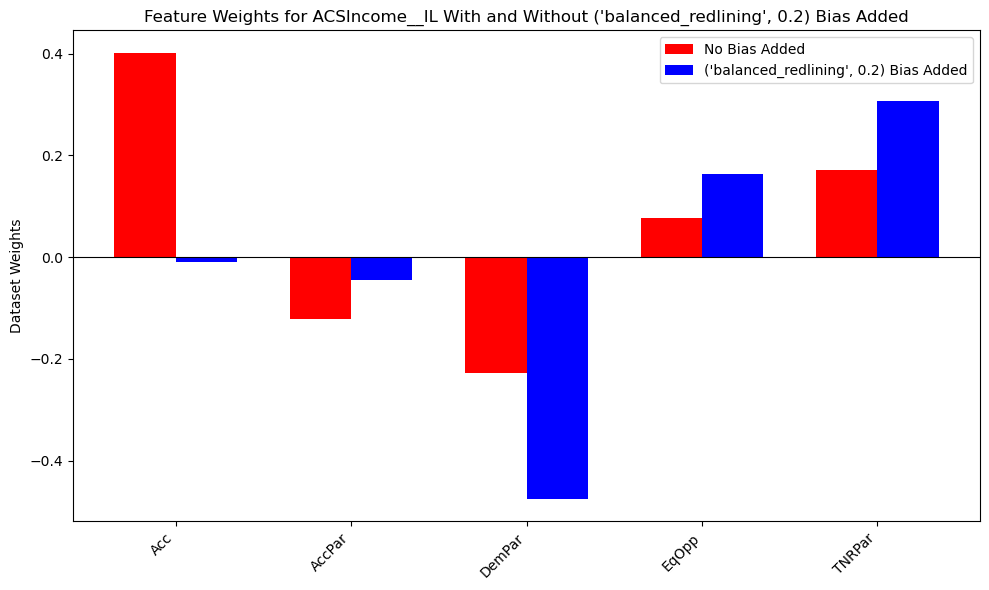

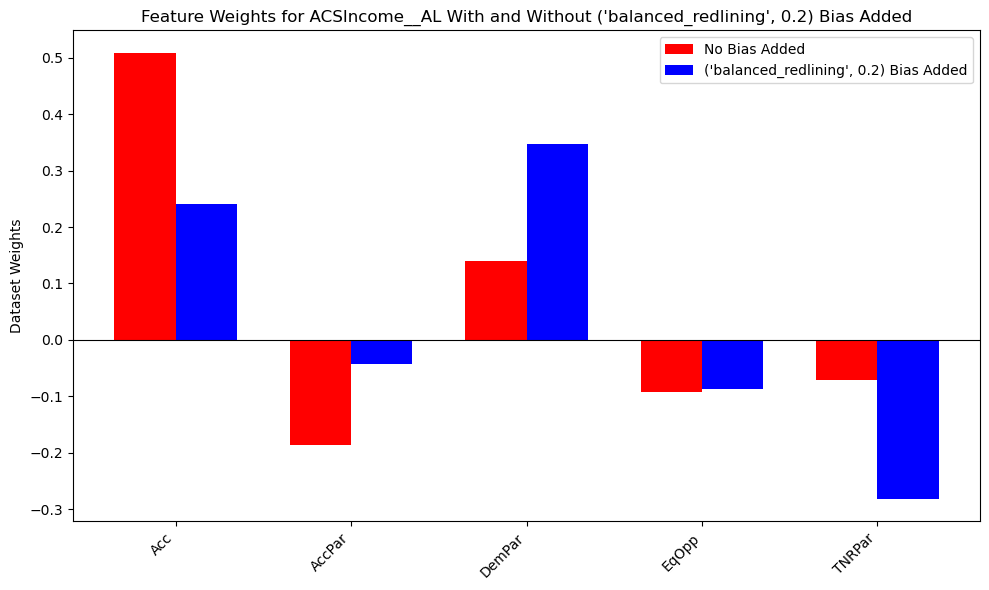

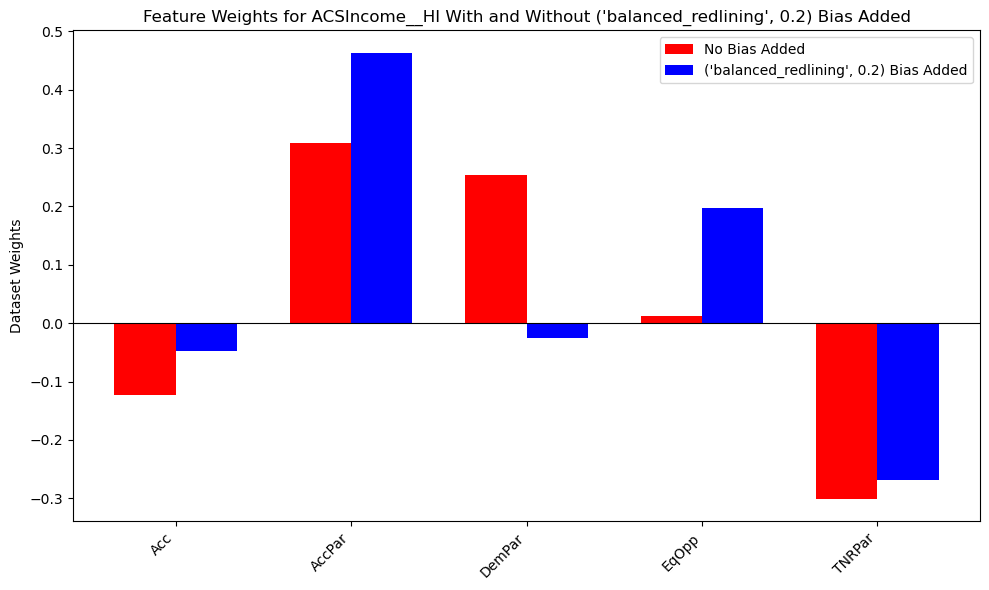

In [9]:
# for section 4, need a version of the "raw" graphs that shows that the weights really do go more negative when we add bias.
# Shows feature weights for each dataset before and after bias is applied.

selected_expert = "OptAcc"
unbiased_type = ()

# biased_type = (("unbalanced_redlining", 0.2),)
biased_type = (("balanced_redlining", 0.2),)
# biased_type = (("perfectly_balanced_redlining", 0.2),)

all_datasets = list(averaged_data.keys())

measurable_metrics = [
    "Acc",
    "AccPar",
    "DemPar",
    "EqOpp",
    "TNRPar",
]

weight_names = ["wL_" + metric for metric in measurable_metrics]

# Retrieve both sets of feature expectations
unadjusted_weights = ()
# adjusted_weights = (("mul_negative_weights", 0.0),)

# Store results: for each dataset, two lists (unbiased, biased)
dataset_results = {}

for dataset in all_datasets:
    # Unadjusted (no weight adjustment)
    unbiased = averaged_data[dataset][selected_expert][unbiased_type][unadjusted_weights][weight_names].values.tolist()
    
    # Zeroed (negative weights set to 0)
    biased = averaged_data[dataset][selected_expert][biased_type][unadjusted_weights][weight_names].values.tolist()
    
    dataset_results[dataset] = (unbiased, biased)

# Plotting
for dataset, (unbiased, biased) in dataset_results.items():
    
    # Bar settings
    x = np.arange(len(measurable_metrics))          # x positions for metrics
    width = 0.35                                     # width of each bar

    fig, ax = plt.subplots(figsize=(10, 6))

    # Colors based on sign (same rule as original snippets)
    # colors_unbias = ['xkcd:blue' if val >= 0 else 'xkcd:red' for val in unbiased]
    # colors_biased = ['xkcd:light blue' if val >= 0 else 'lightcoral' for val in biased]
    colors_unbias = "red"
    colors_biased = "blue"

    # Clustered bars: unbiased on the left, biased on the right
    ax.bar(x - width/2, unbiased, width, label='No Bias Added', color=colors_unbias)
    ax.bar(x + width/2, biased, width, label=f'{biased_type[0]} Bias Added', color=colors_biased)

    # Labels and title
    ax.set_ylabel('Dataset Weights')
    ax.set_title(f"Feature Weights for {dataset} With and Without {biased_type[0]} Bias Added")
    ax.set_xticks(x)
    ax.set_xticklabels(measurable_metrics, rotation=45, ha='right')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.legend()

    plt.tight_layout()
    
    # Save and show
    plt.savefig(f"./../../data/experiment_output/fair_irl/exp_plots/Unbiased_vs_Biased_Feature_Weights_{dataset}.pdf", bbox_inches="tight")
    plt.show()

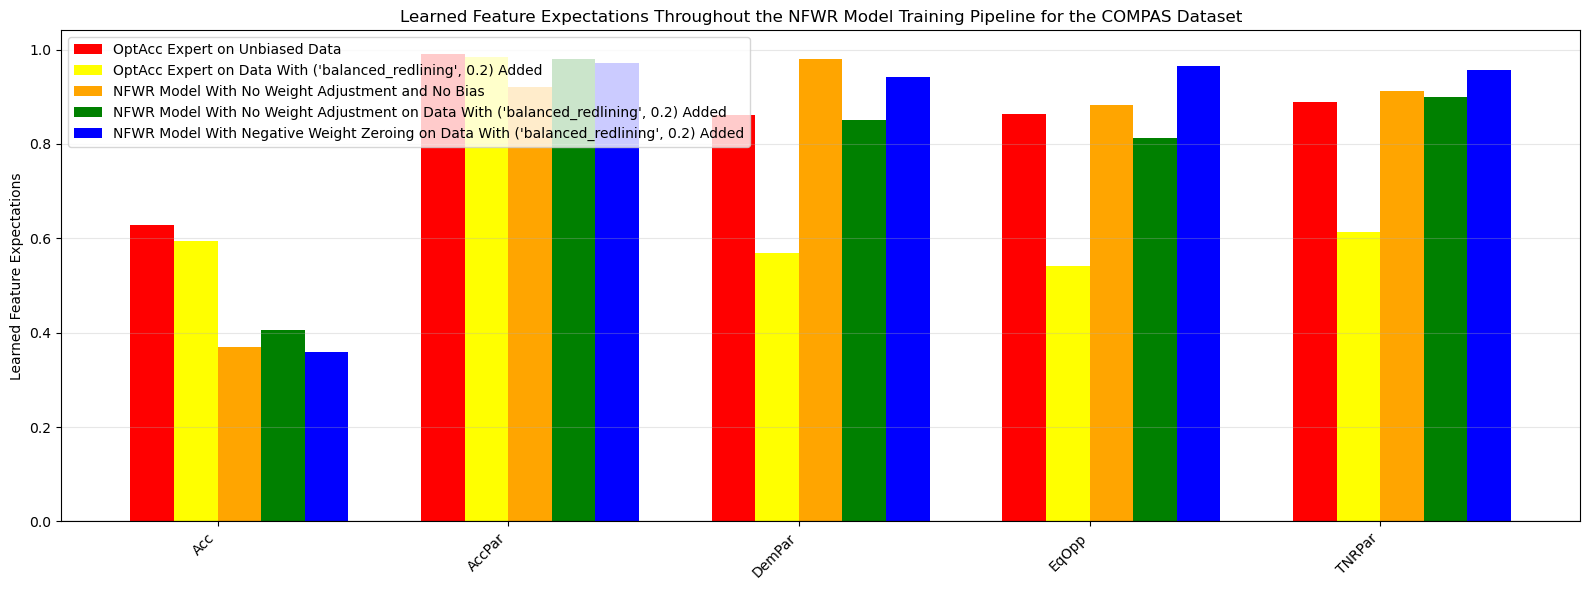

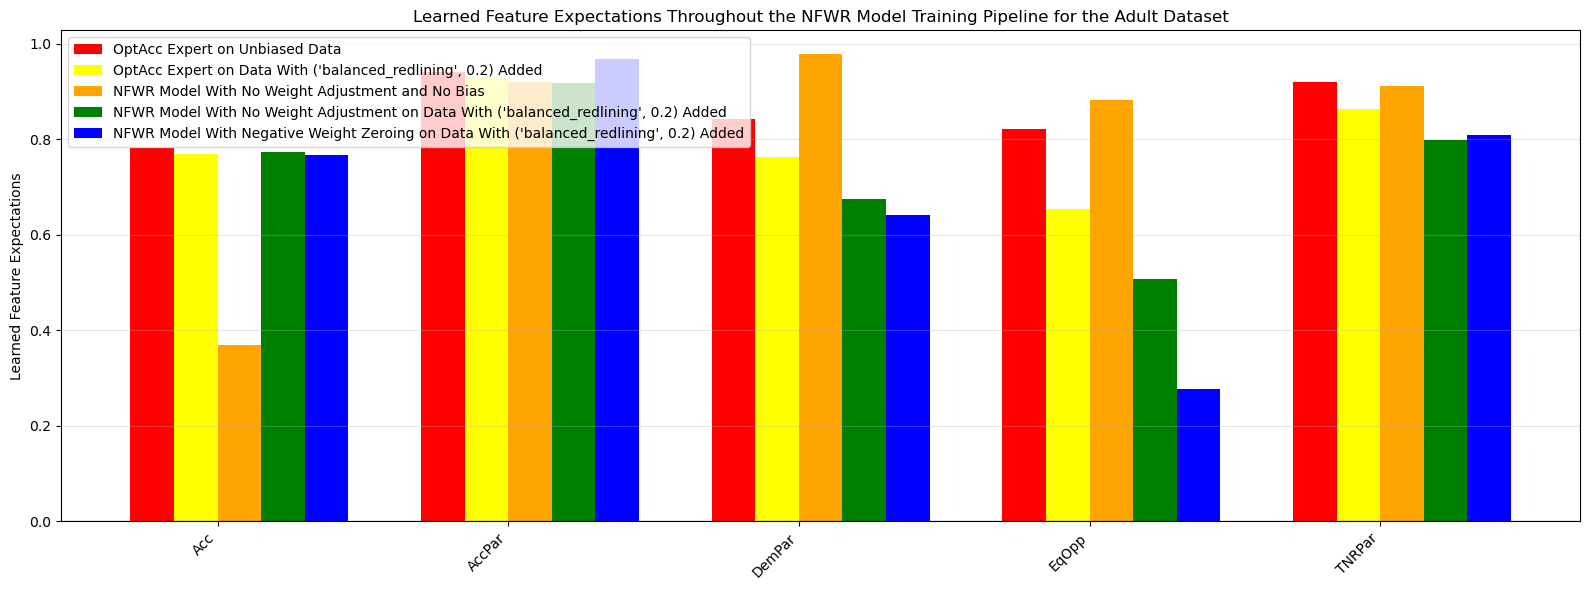

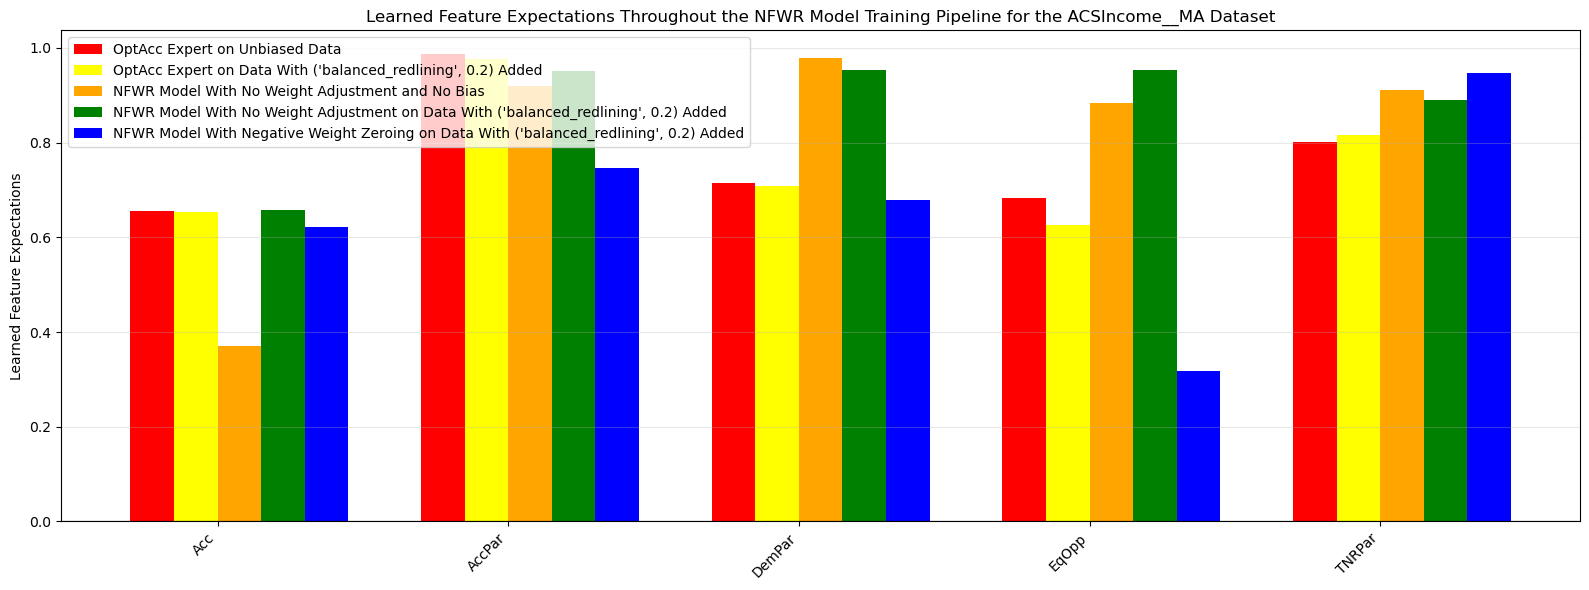

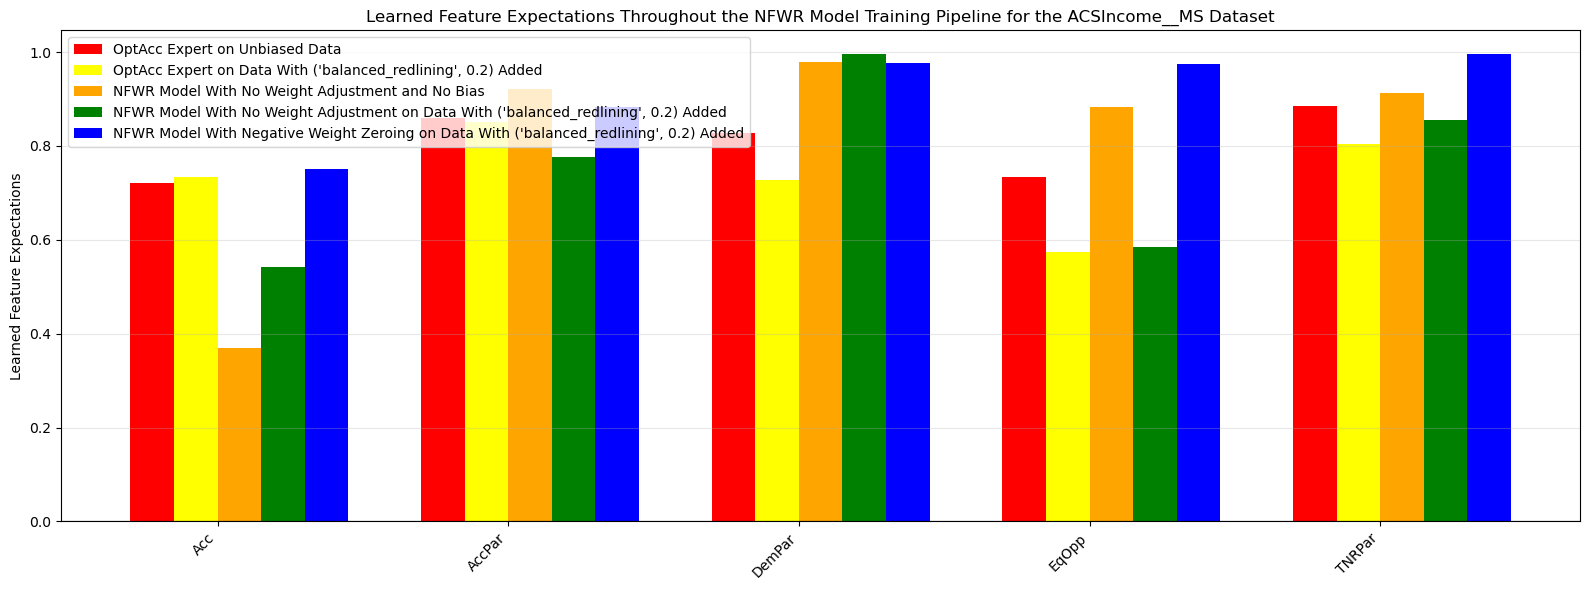

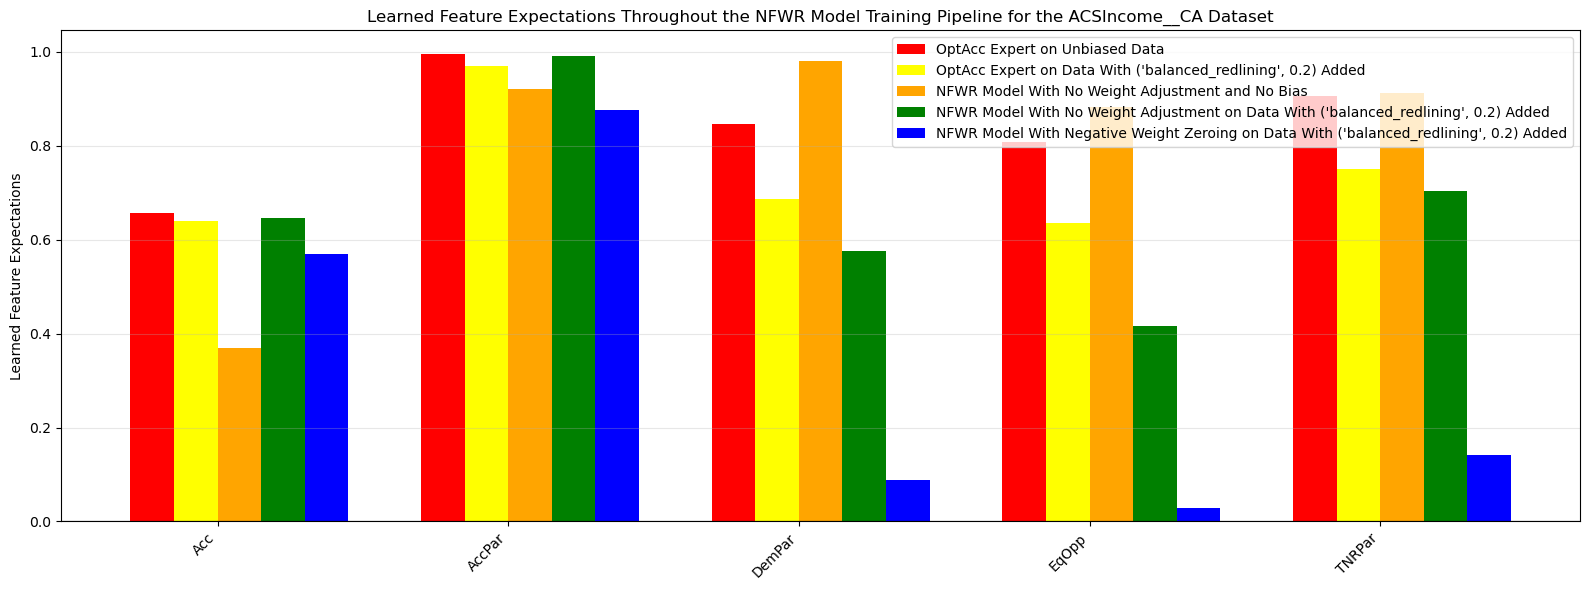

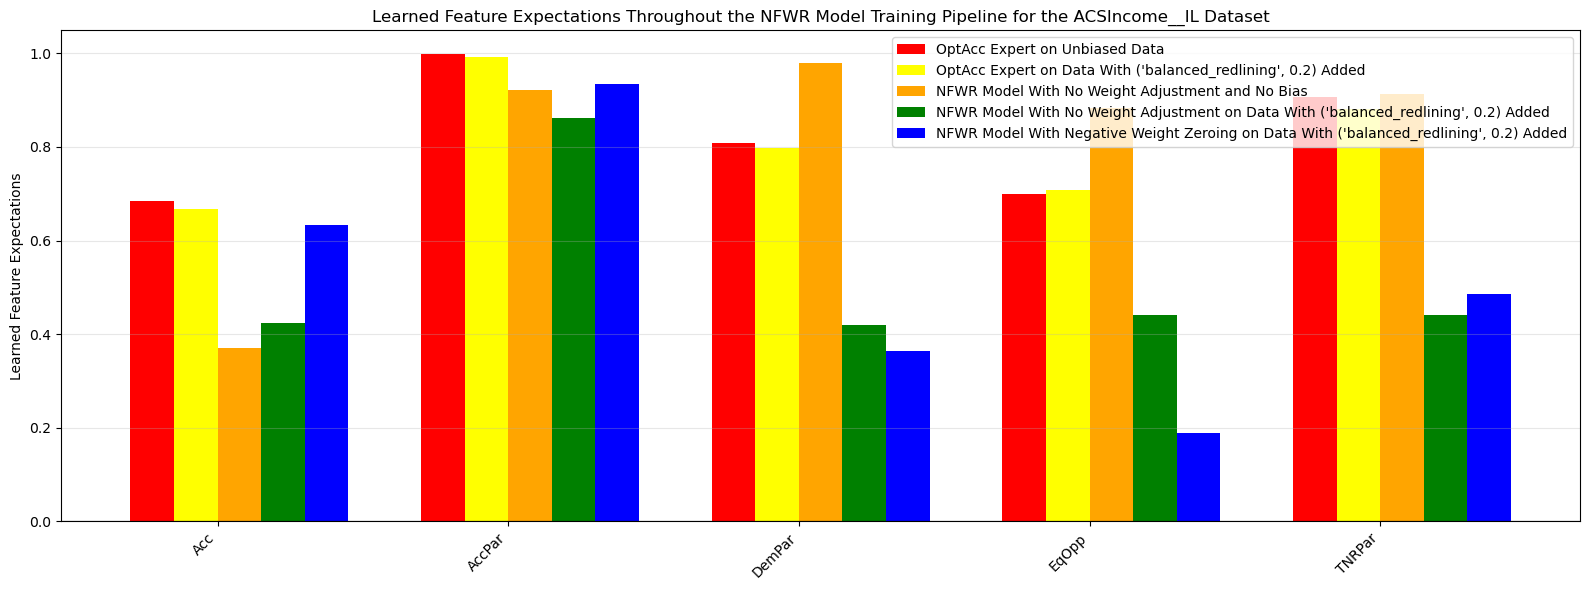

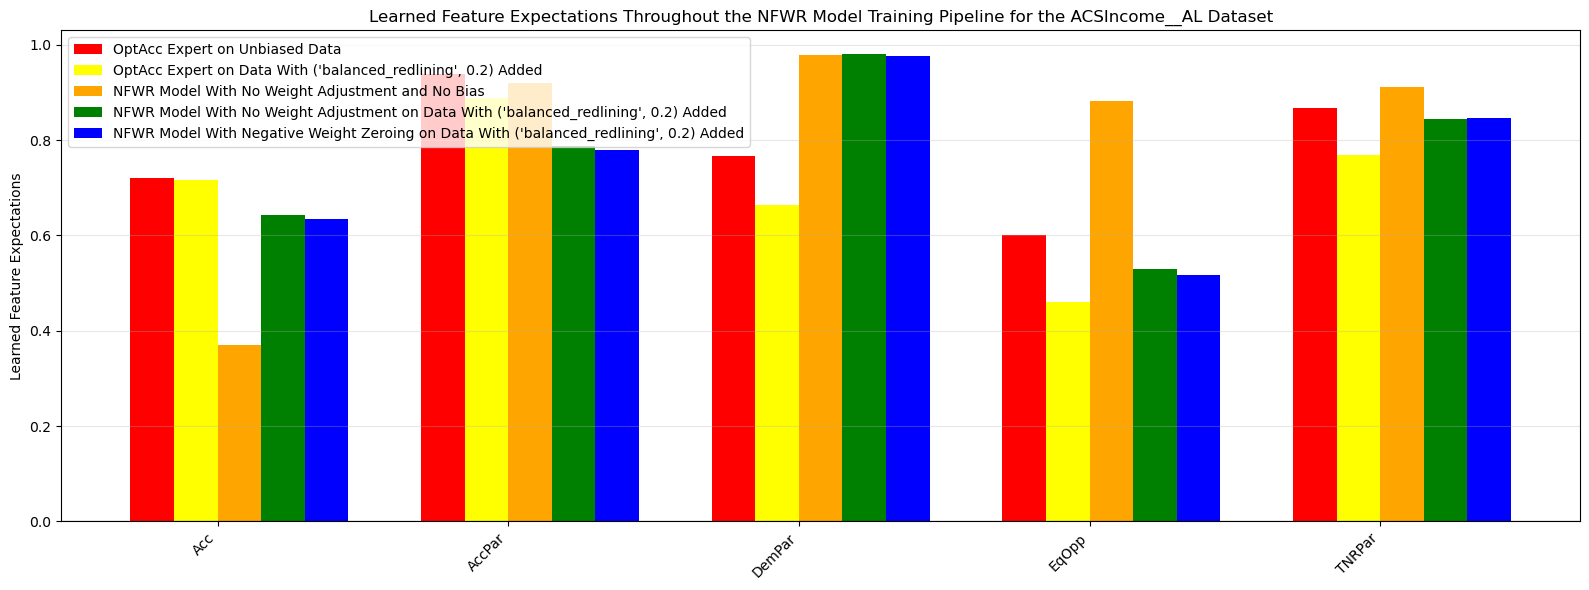

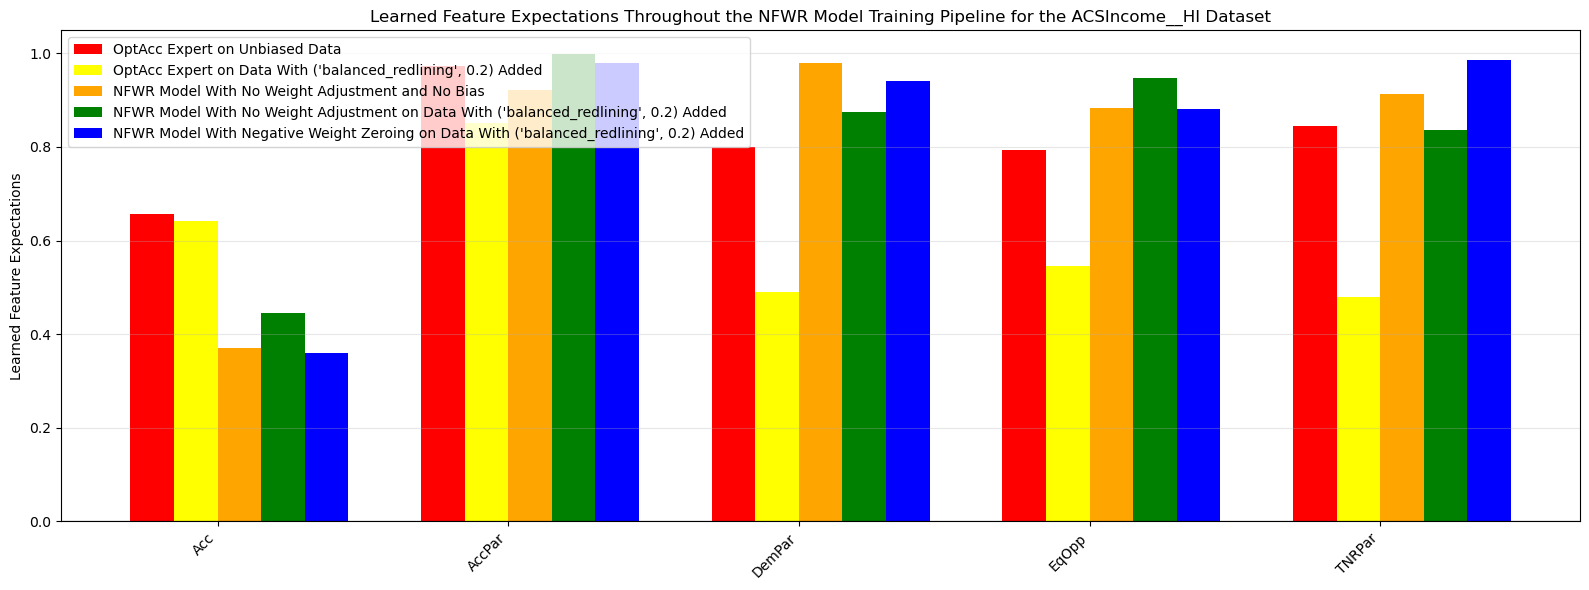

In [10]:
# Visualize what happens to the feature expectations throughout the training process if you fully zero the negative weights for each dataset. Show that if you just zero the negative weights, you get something where the feature expectations dont match what the expert originally was attempting
# feature expectations of the dataset with no bias
# feature expectations of the dataset with bias added
# feature expectations of Fair-IRL trained on bias with no zeroing
# Feature expectations of Fair-IRL trained on bias with zeroing

selected_expert = "OptAcc"
unbiased_type = ()
# biased_type = (("unbalanced_redlining", 0.2),)
biased_type = (("balanced_redlining", 0.2),)
# biased_type = (("perfectly_balanced_redlining", 0.2),)

all_datasets = [
    "COMPAS",
    # "Boston",
    "Adult",
    "ACSIncome__MA",
    "ACSIncome__MS",
    "ACSIncome__CA",
    "ACSIncome__IL",
    "ACSIncome__AL",
    "ACSIncome__HI",
]

measurable_metrics = [
    "Acc",
    "AccPar",
    "DemPar",
    "EqOpp",
    "TNRPar",
]

muE_test_unbiased_names = ["muE_test_unbiased_" + metric + "_mean" for metric in measurable_metrics]
muE_test_names = ["muE_test_" + metric + "_mean" for metric in measurable_metrics]
muL_test_names = ["muL_test_" + metric for metric in measurable_metrics]

unadjusted_weights = ()
# adjusted_weights = (("mul_negative_weights", 0.0),)
adjusted_weights = (("ml_debias",),)

dataset_results = {}

for dataset in all_datasets:
    muE_test_unbiased = averaged_data[dataset][selected_expert][unbiased_type][unadjusted_weights][muE_test_unbiased_names].values.tolist()
    
    muE_test = averaged_data[dataset][selected_expert][biased_type][unadjusted_weights][muE_test_names].values.tolist()

    muL_test_unbiased = averaged_data[dataset][selected_expert][unbiased_type][unadjusted_weights][muL_test_names].values.tolist()

    muL_test_unadjusted = averaged_data[dataset][selected_expert][biased_type][unadjusted_weights][muL_test_names].values.tolist()

    muL_test_zeroed = averaged_data[dataset][selected_expert][biased_type][adjusted_weights][muL_test_names].values.tolist()
    
    dataset_results[dataset] = (muE_test_unbiased, muE_test, muL_test_unadjusted, muL_test_zeroed)

# Plotting
for dataset, (muE_test_unbiased, muE_test, muL_test_unadjusted, muL_test_zeroed) in dataset_results.items():
    
    # Bar settings - FIXED: Use 4 bars per cluster with proper positioning
    x = np.arange(len(measurable_metrics))  # x positions for metrics
    width = 0.15  # width of each bar (narrower to fit 4 bars)
    
    fig, ax = plt.subplots(figsize=(16, 6))

    colors_muE_test_unbiased = "red"
    colors_muE_test = "yellow"
    colors_muL_test_unbiased = "orange"
    colors_muL_test_unadjusted = "green"
    colors_muL_test_zeroed = "blue"

    # Clustered bars - FIXED: Proper positioning for 4 bars
    # Calculate offsets so bars are evenly spaced around each x position
    ax.bar(x - 1.5*width, muE_test_unbiased, width, 
           label='OptAcc Expert on Unbiased Data', color=colors_muE_test_unbiased)
    ax.bar(x - 0.5*width, muE_test, width, 
           label=f'OptAcc Expert on Data With {biased_type[0]} Added', color=colors_muE_test)
    ax.bar(x + 0.5*width, muL_test_unbiased, width, 
           label='NFWR Model With No Weight Adjustment and No Bias', color=colors_muL_test_unbiased)
    ax.bar(x + 1.5*width, muL_test_unadjusted, width, 
           label=f'NFWR Model With No Weight Adjustment on Data With {biased_type[0]} Added', color=colors_muL_test_unadjusted)
    ax.bar(x + 2.5*width, muL_test_zeroed, width, 
           label=f'NFWR Model With Negative Weight Zeroing on Data With {biased_type[0]} Added', color=colors_muL_test_zeroed)

    # Labels and title
    ax.set_ylabel('Learned Feature Expectations')
    ax.set_title(f"Learned Feature Expectations Throughout the NFWR Model Training Pipeline for the {dataset} Dataset")
    ax.set_xticks(x)
    ax.set_xticklabels(measurable_metrics, rotation=45, ha='right')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.legend()
    
    # Add grid for better readability
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    
    # Save and show
    plt.savefig(f"./../../data/experiment_output/fair_irl/exp_plots/Learned_Feat_Exp_of_Train_Pipeline_{dataset}.pdf", bbox_inches="tight")
    plt.show()

In [11]:
# Compute different experts with different values of difference_bound, then graph how that affects the accuracy/fairness tradeoff, show that in the intro (show that our learned weights preserve the fairness tradeoff from the expert)
selected_experts = [
    "DemParRed", "DemParRed_0.1", "DemParRed_0.2", "DemParRed_0.3", "DemParRed_0.4",
    "DemParRed_0.5", "DemParRed_0.6", "DemParRed_0.7", "DemParRed_0.8", "DemParRed_0.9",
    "DemParRed_1.0"
]

selected_datasets = ["Adult"]
measurable_metrics = ["Acc", "AccPar", "DemPar", "EqOpp", "TNRPar"]
weight_names = ["wL_" + metric for metric in measurable_metrics]
unbiased_type = ()
unadjusted_weights = ()

dataset_results = {}

for dataset in selected_datasets:
    weights_per_expert = []
    for expert in selected_experts:
        weights = (
            averaged_data[dataset][expert][unbiased_type][unadjusted_weights][
                weight_names
            ].values.tolist()
        )
        weights_per_expert.append(weights)
    dataset_results[dataset] = weights_per_expert


# ====================== PLOTTING ======================
for dataset, weights_per_expert in dataset_results.items():

    num_experts = len(selected_experts)
    x = np.arange(len(measurable_metrics))
    total_group_width = 0.8
    width = total_group_width / num_experts
    offsets = [(i - (num_experts - 1) / 2) * width for i in range(num_experts)]

    fig, ax = plt.subplots(figsize=(20, 6))

    # === RAINBOW PALETTE: Red → Violet within each cluster ===
    # Using 'rainbow' colormap (red at 0, violet at 1)
    cmap = plt.cm.get_cmap('rainbow')

    for i, (expert_weights, expert) in enumerate(zip(weights_per_expert, selected_experts)):
        
        # Normalize expert index to [0, 1] → continuous transition
        color = cmap(i / (num_experts - 1))   # 0.0 = Red, 1.0 = Violet

        ax.bar(
            x + offsets[i],
            expert_weights,
            width,
            label=expert,
            color=color
        )

    # Labels and formatting
    ax.set_ylabel("Feature Weight Values")
    ax.set_title(f"Feature Weights for Different Fairness Tradeoffs on {dataset} Dataset")
    ax.set_xticks(x)
    ax.set_xticklabels(measurable_metrics, rotation=45, ha="right")
    ax.axhline(0, color="black", linewidth=0.8)

    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.tight_layout()

    plt.savefig(
        f"./../../data/experiment_output/fair_irl/exp_plots/Fairness_Tradeoffs_Showcase_{dataset}.pdf",
        bbox_inches="tight"
    )
    plt.show()

KeyError: "None of [Index(['wL_Acc', 'wL_AccPar', 'wL_DemPar', 'wL_EqOpp', 'wL_TNRPar'], dtype='object')] are in the [columns]"